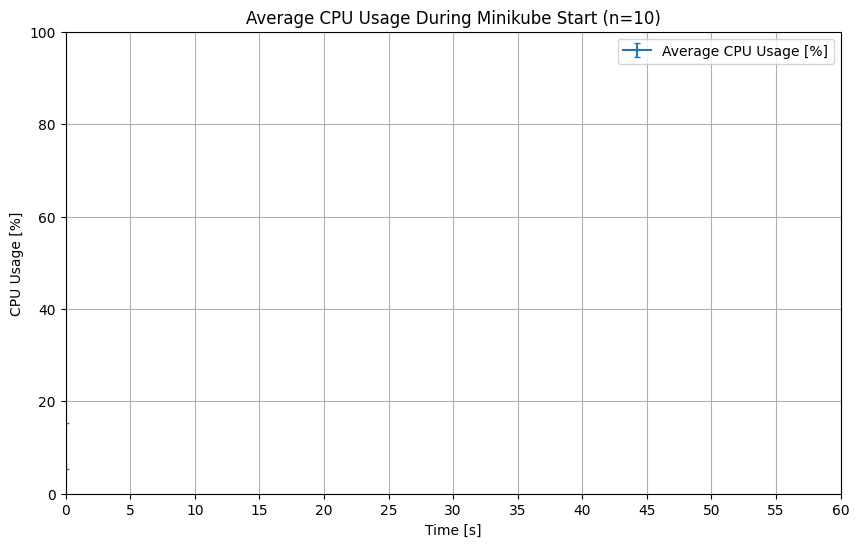

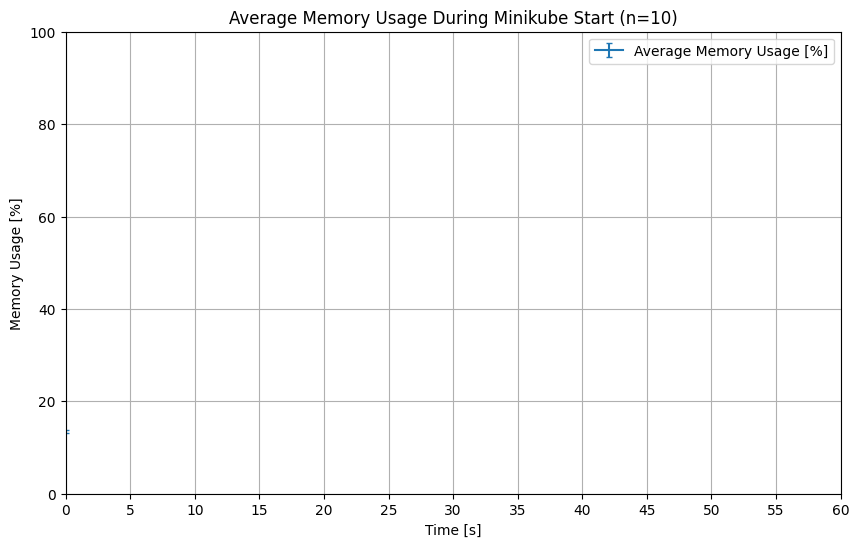

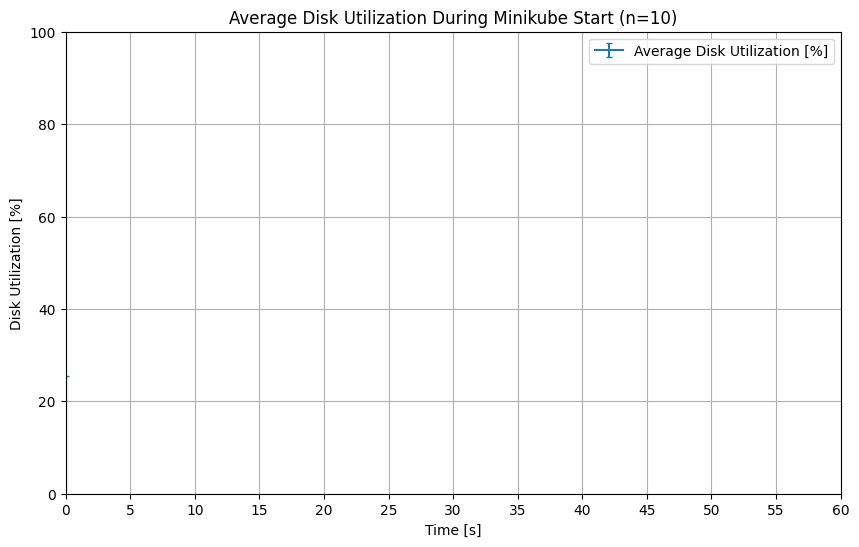

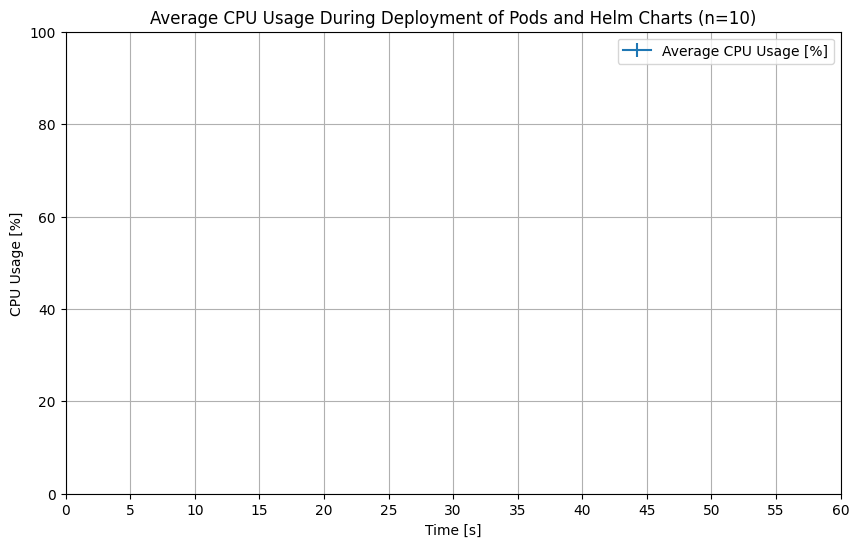

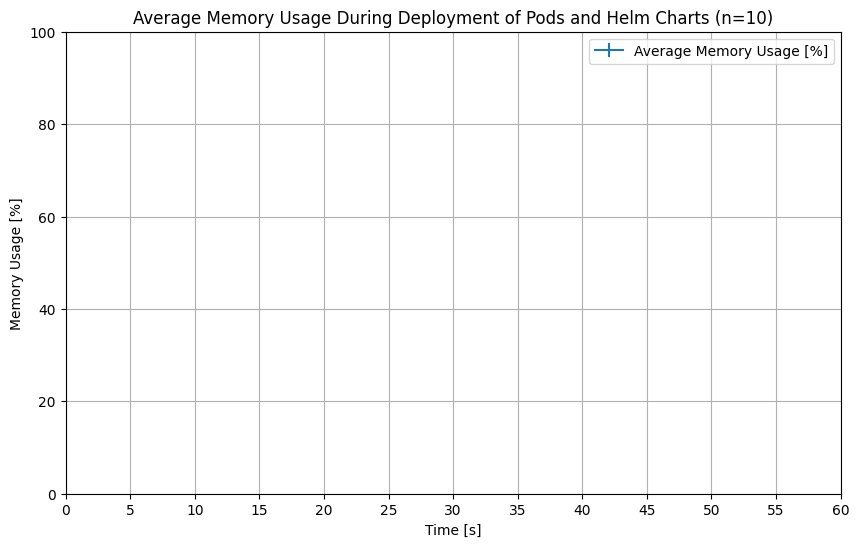

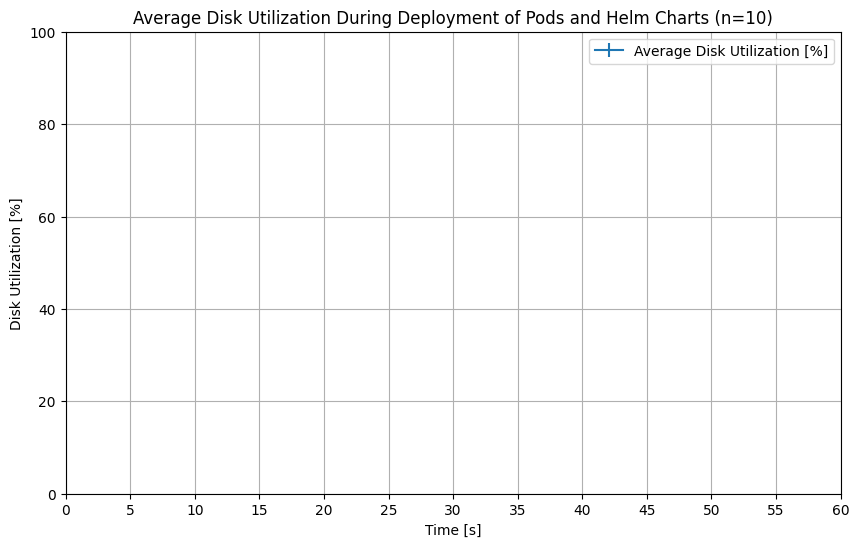

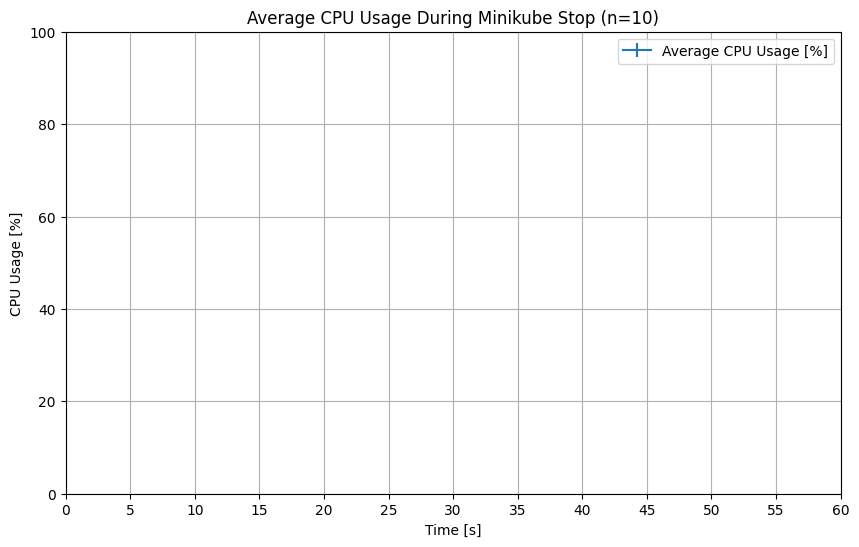

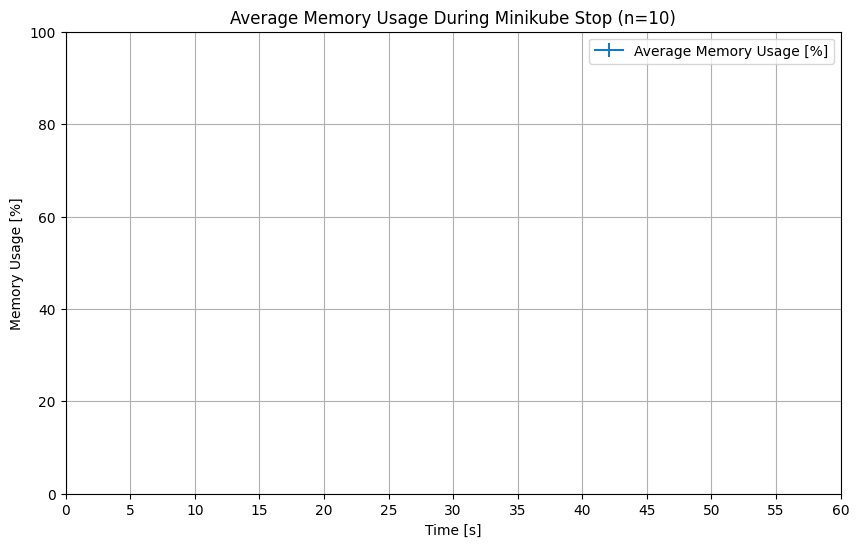

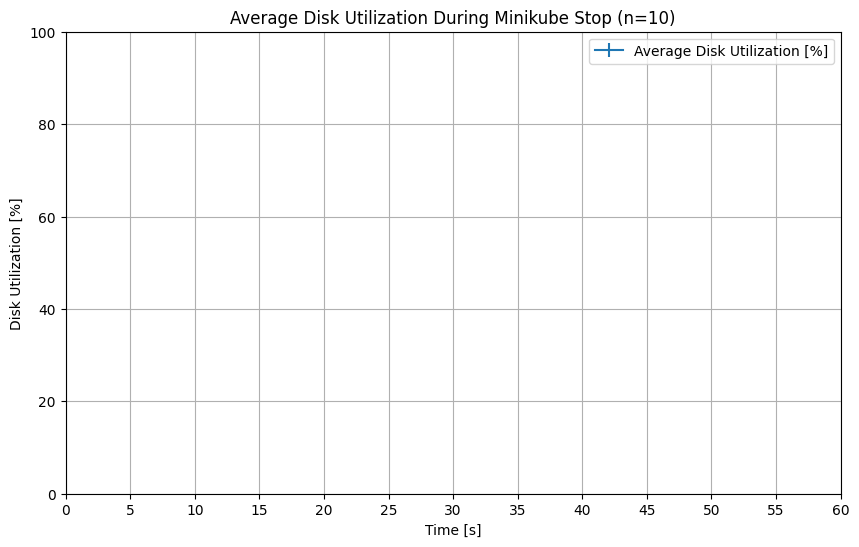

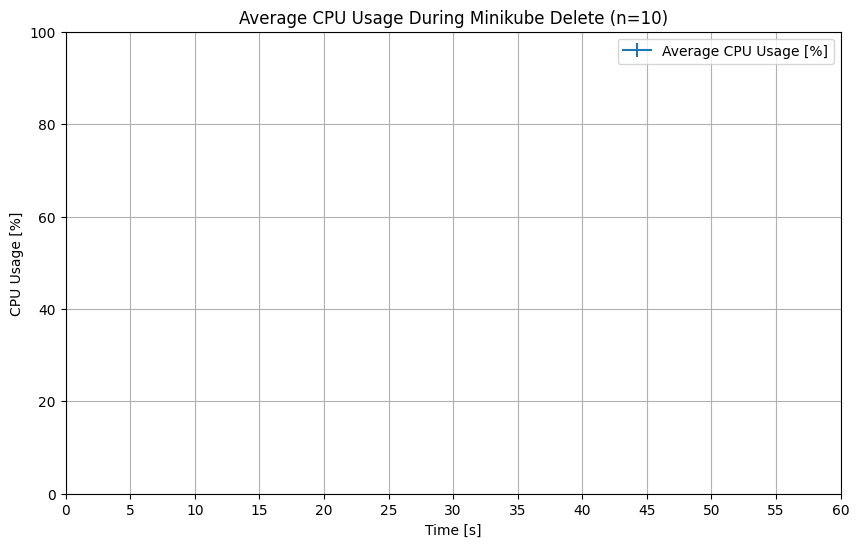

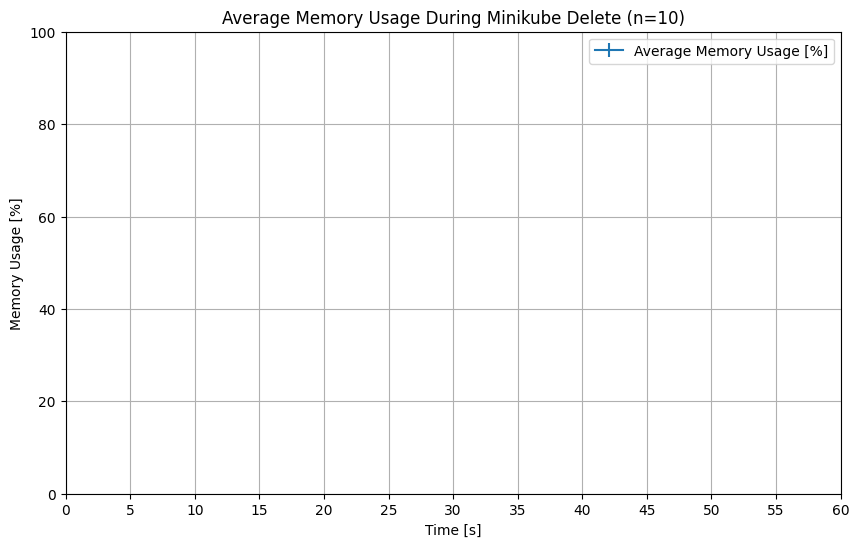

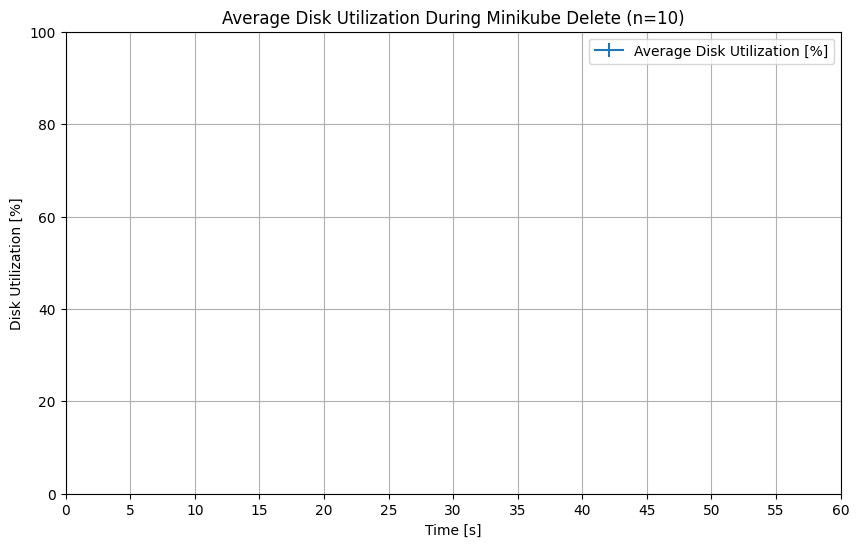

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

NUM_FILES = 10

phases_data = {
    'start': [],
    'deployment': [],
    'end': [],
    'delete': []
}

# Read all CSV files
for i in range(1, NUM_FILES + 1):
    phases_data['start'].append(pd.read_csv(f"results/start_{i}.csv"))
    phases_data['deployment'].append(pd.read_csv(f"results/deployment_{i}.csv"))
    phases_data['end'].append(pd.read_csv(f"results/end_{i}.csv"))
    phases_data['delete'].append(pd.read_csv(f"results/delete_{i}.csv"))

# print(phases_data)

# Calculate averages and standard deviations for each phase
avg_metrics = {}
std_metrics = {}
for phase, dfs in phases_data.items():
    # Initialize DataFrames
    avg_metrics[phase] = pd.DataFrame()
    std_metrics[phase] = pd.DataFrame()
    
    # Find minimum length across all files for this phase
    min_length = min(len(df) for df in dfs)
    
    # Trim all dataframes to minimum length
    dfs_trimmed = [df.iloc[:min_length] for df in dfs]
    
    # Use timestamp from first file
    avg_metrics[phase]['timestamp'] = dfs_trimmed[0]['timestamp'].str.replace('s', '').astype(float)
    
    # Calculate averages and std for each metric
    metrics = ['cpu_usage_percent', 'mem_usage_percent', 'disk_usage_percent']
    for metric in metrics:
        values = np.array([df[metric].values[:min_length] for df in dfs])
        avg_metrics[phase][metric] = np.mean(values, axis=0)
        std_metrics[phase][metric] = np.std(values, axis=0)
    
    # print('Metric:',metric)
    # print('Phase', phase)
    # print(std_metrics[phase][metric])

# Plot averaged results with error bars
phase_names = {
    'start': "Minikube Start",
    'deployment': "Deployment of Pods and Helm Charts",
    'end': "Minikube Stop",
    'delete': "Minikube Delete"
}

for phase, data in avg_metrics.items():
    # CPU Usage
    plt.figure(figsize=(10, 6))
    plt.errorbar(data['timestamp'], 
                data['cpu_usage_percent'],
                yerr=std_metrics[phase]['cpu_usage_percent'],
                label='Average CPU Usage [%]',
                capsize=2)
    plt.title(f"Average CPU Usage During {phase_names[phase]} (n={NUM_FILES})")
    plt.xlim(0, 60)
    plt.xticks(np.arange(0, 65, 5))
    plt.ylim(0, 100)
    plt.xlabel("Time [s]")
    plt.ylabel("CPU Usage [%]")
    plt.grid()
    plt.legend()
    plt.show()

    # Memory Usage
    plt.figure(figsize=(10, 6))
    plt.errorbar(data['timestamp'], 
                data['mem_usage_percent'],
                yerr=std_metrics[phase]['mem_usage_percent'],
                label='Average Memory Usage [%]',
                capsize=2)
    plt.title(f"Average Memory Usage During {phase_names[phase]} (n={NUM_FILES})")
    plt.xlim(0, 60)
    plt.xticks(np.arange(0, 65, 5))
    plt.ylim(0, 100)
    plt.xlabel("Time [s]")
    plt.ylabel("Memory Usage [%]")
    plt.grid()
    plt.legend()
    plt.show()

    # Disk Usage
    plt.figure(figsize=(10, 6))
    plt.errorbar(data['timestamp'], 
                data['disk_usage_percent'],
                yerr=std_metrics[phase]['disk_usage_percent'],
                label='Average Disk Utilization [%]',
                capsize=2)
    plt.title(f"Average Disk Utilization During {phase_names[phase]} (n={NUM_FILES})")
    plt.xlim(0, 60)
    plt.xticks(np.arange(0, 65, 5))
    plt.ylim(0, 100)
    plt.xlabel("Time [s]")
    plt.ylabel("Disk Utilization [%]")
    plt.grid()
    plt.legend()
    plt.show()


k3s - start:
Number of files loaded: 10
First file shape: (13, 6)

k3s - deployment:
Number of files loaded: 10
First file shape: (25, 6)

k3s - end:
Number of files loaded: 10
First file shape: (13, 6)

k3s - delete:
Number of files loaded: 10
First file shape: (13, 6)

minikube_nowy - start:
Number of files loaded: 10
First file shape: (13, 6)

minikube_nowy - deployment:
Number of files loaded: 10
First file shape: (61, 6)

minikube_nowy - end:
Number of files loaded: 10
First file shape: (13, 6)

minikube_nowy - delete:
Number of files loaded: 10
First file shape: (13, 6)


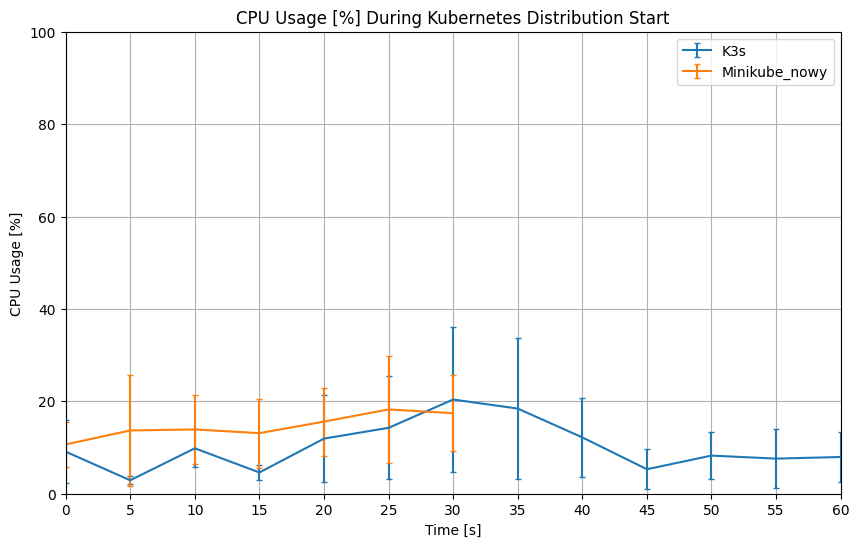

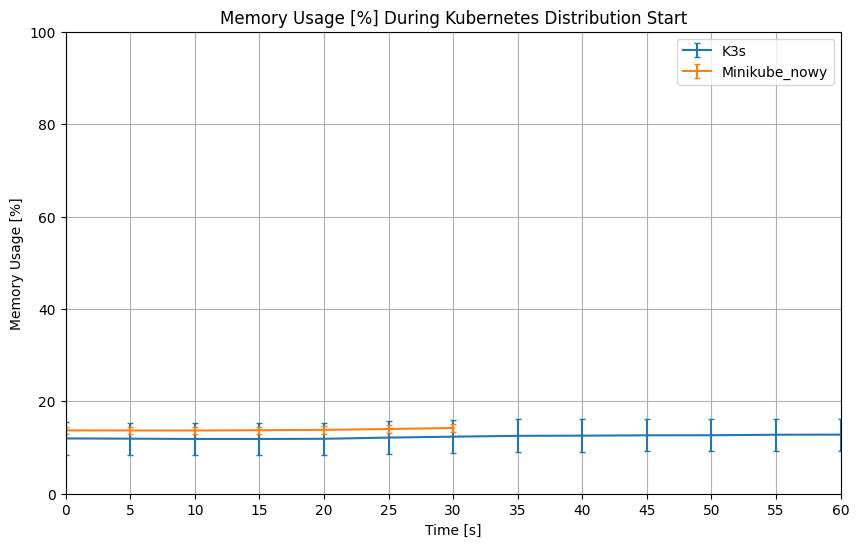

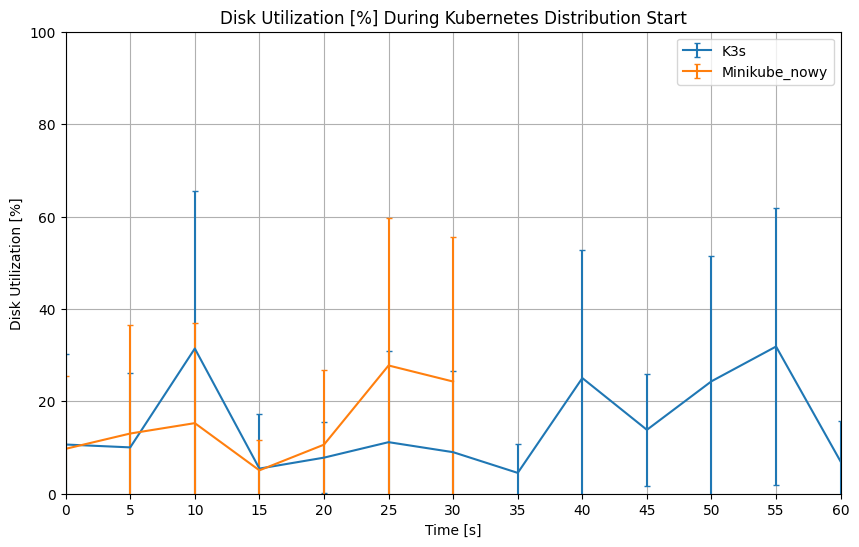

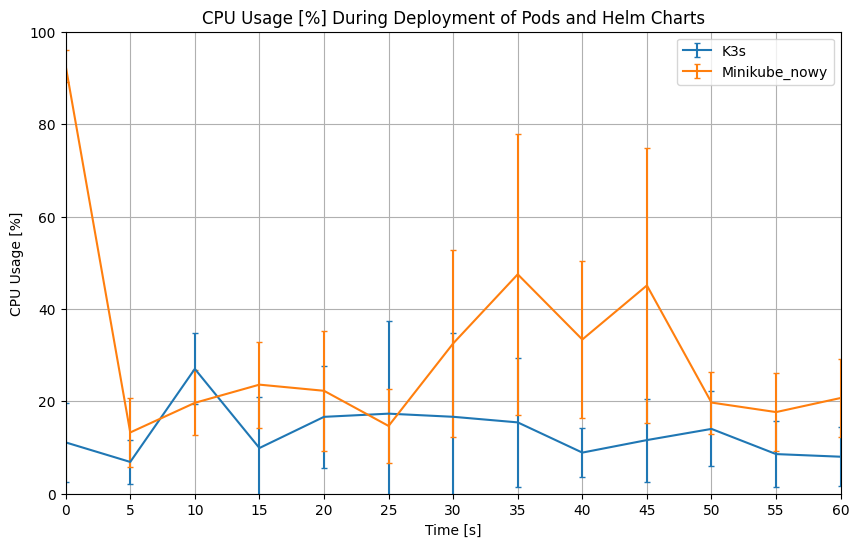

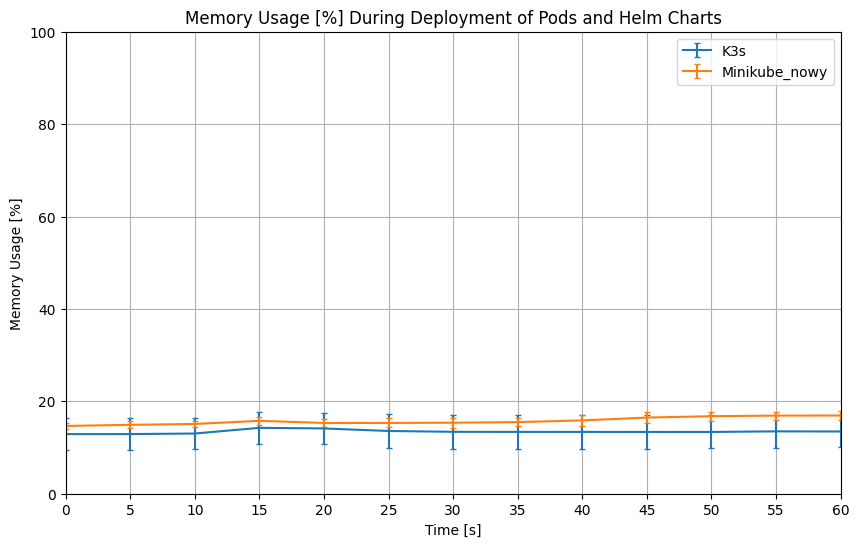

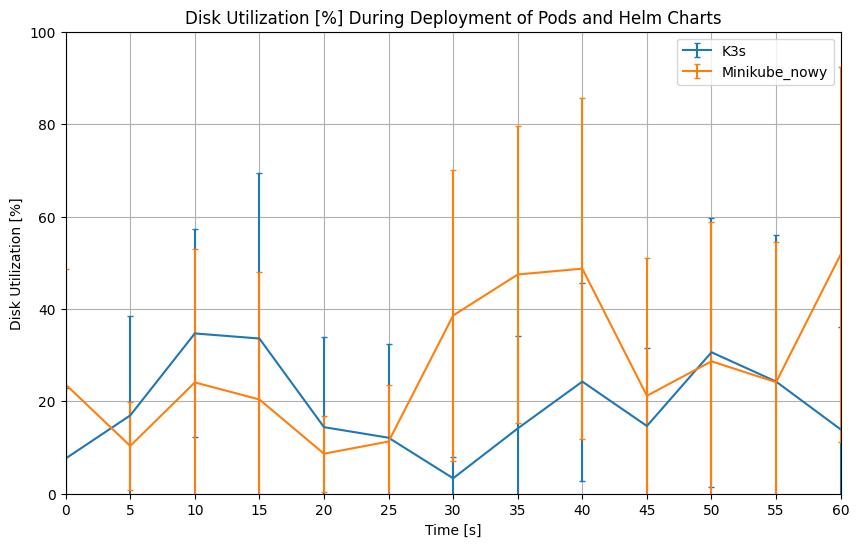

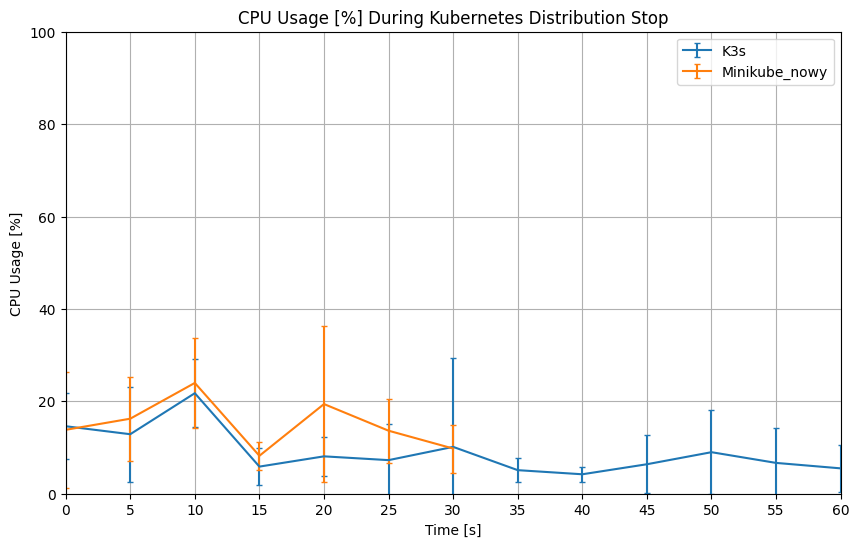

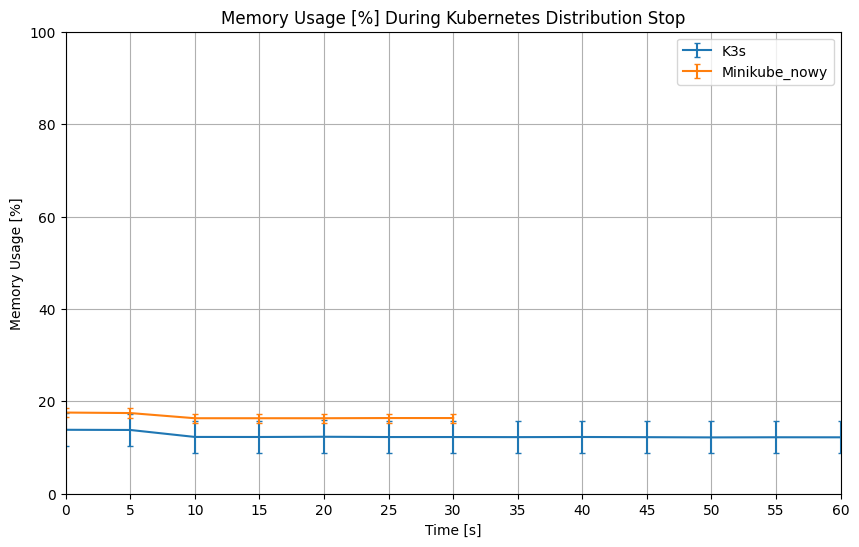

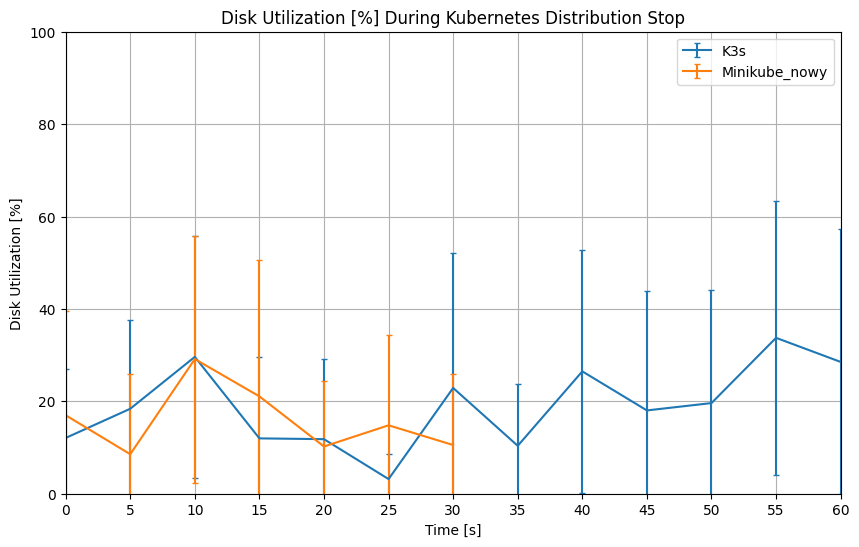

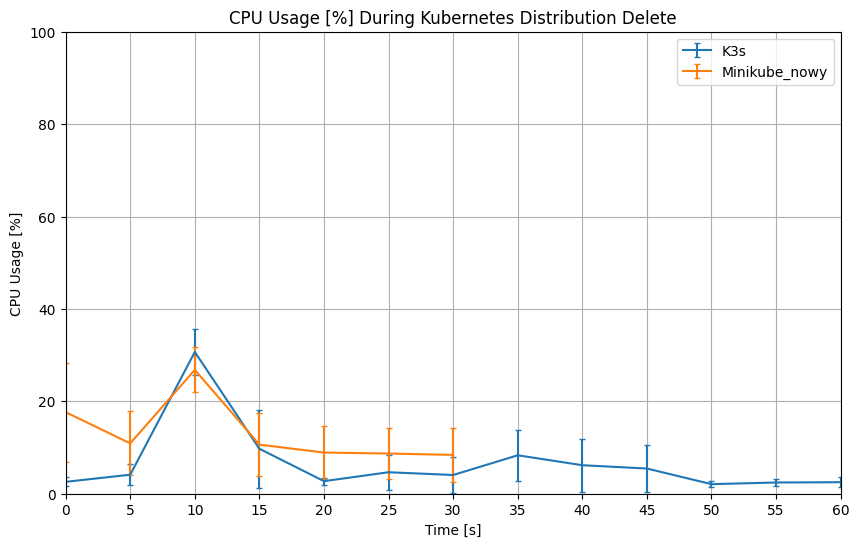

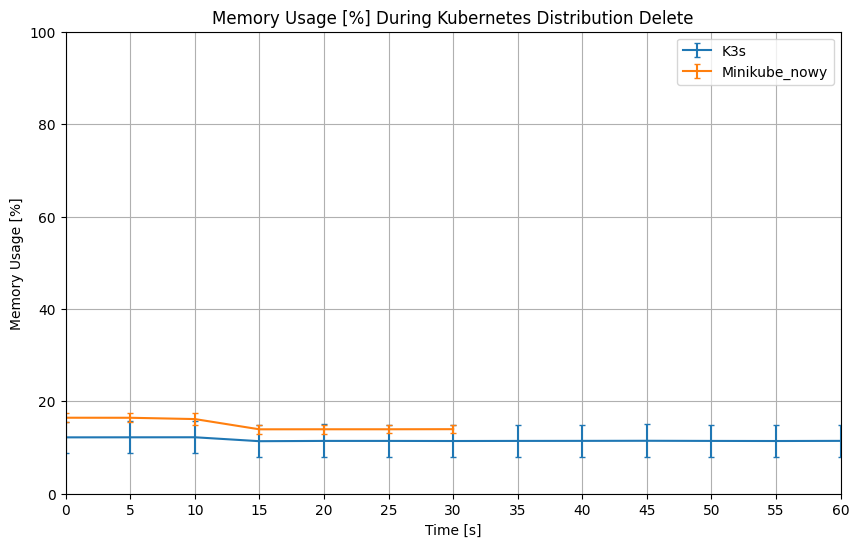

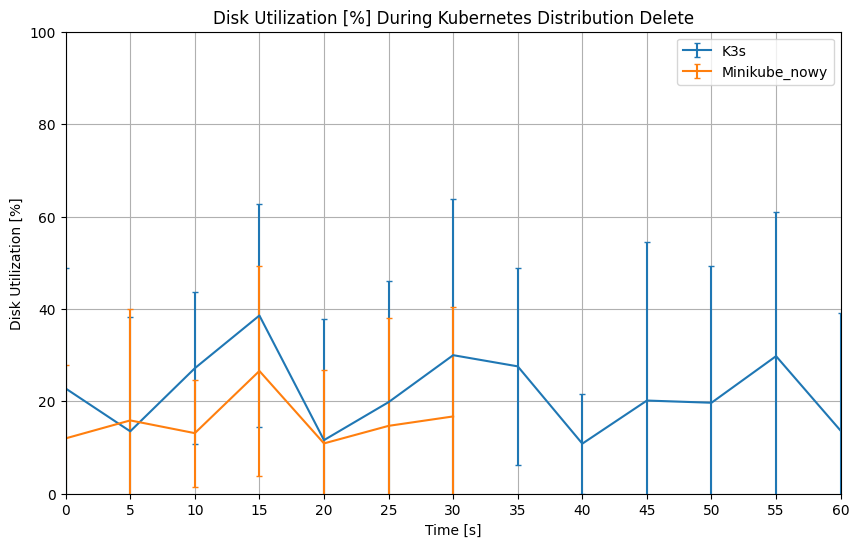

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

NUM_FILES = 10


sources = {
    'k3s': 'k3s-cpu_mem',
    'minikube_nowy': 'results'
}

data = {
    source: {
        'start': [],
        'deployment': [],
        'end': [],
        'delete': []
    } for source in sources
}

for source, directory in sources.items():
    for i in range(1, NUM_FILES + 1):
        for phase in data[source]:
            try:
                file_path = f"{directory}/{phase}_{i}.csv"
                if os.path.exists(file_path):
                    df = pd.read_csv(file_path)
                    if not df.empty:
                        data[source][phase].append(df)
                    else:
                        print(f"Empty file: {file_path}")
                else:
                    print(f"File not found: {file_path}")
            except Exception as e:
                print(f"Error reading {file_path}: {str(e)}")

# Add debug prints for loaded data
for source in sources:
    for phase in data[source]:
        print(f"\n{source} - {phase}:")
        print(f"Number of files loaded: {len(data[source][phase])}")
        if data[source][phase]:
            print(f"First file shape: {data[source][phase][0].shape}")

for source, directory in sources.items():
    for i in range(1, NUM_FILES + 1):
        for phase in data[source]:
            data[source][phase].append(pd.read_csv(f"{directory}/{phase}_{i}.csv"))

avg_metrics = {source: {} for source in sources}
std_metrics = {source: {} for source in sources}

for source in sources:
    for phase, dfs in data[source].items():
        avg_metrics[source][phase] = pd.DataFrame()
        std_metrics[source][phase] = pd.DataFrame()
        
        #TODO: usunąć jak będą dane z k3s
        min_length = min(len(df) for df in dfs)
        dfs_trimmed = [df.iloc[:min_length] for df in dfs]
        
        avg_metrics[source][phase]['timestamp'] = dfs_trimmed[0]['timestamp'].str.replace('s', '').astype(float)
        
        for metric in ['cpu_usage_percent', 'mem_usage_percent', 'disk_usage_percent']:
            values = np.array([df[metric].values[:min_length] for df in dfs])
            # dzięki axis=0 bierze po pierwszym elemencie z każdego DataFrame
            avg_metrics[source][phase][metric] = np.mean(values, axis=0)
            std_metrics[source][phase][metric] = np.std(values, axis=0)
        # print(avg_metrics[source][phase])
        # print(source, phase)
        # print(std_metrics[source][phase])

phases = {
    'start': "Kubernetes Distribution Start",
    'deployment': "Deployment of Pods and Helm Charts",
    'end': "Kubernetes Distribution Stop",
    'delete': "Kubernetes Distribution Delete"
}

metrics = {
    'cpu_usage_percent': 'CPU Usage [%]',
    'mem_usage_percent': 'Memory Usage [%]',
    'disk_usage_percent': 'Disk Utilization [%]'
}

for phase, phase_title in phases.items():
    for metric, metric_label in metrics.items():
        plt.figure(figsize=(10, 6))
        
        for source in sources:
            plt.errorbar(
                avg_metrics[source][phase]['timestamp'],
                avg_metrics[source][phase][metric],
                yerr=std_metrics[source][phase][metric],
                label=source.capitalize(),
                capsize=2
            )
        
        plt.title(f"{metric_label} During {phase_title}")
        plt.xlim(0, 60)
        plt.xticks(np.arange(0, 65, 5))
        plt.ylim(0, 100)
        plt.xlabel("Time [s]")
        plt.ylabel(metric_label)
        plt.grid(True)
        plt.legend()
        plt.show()

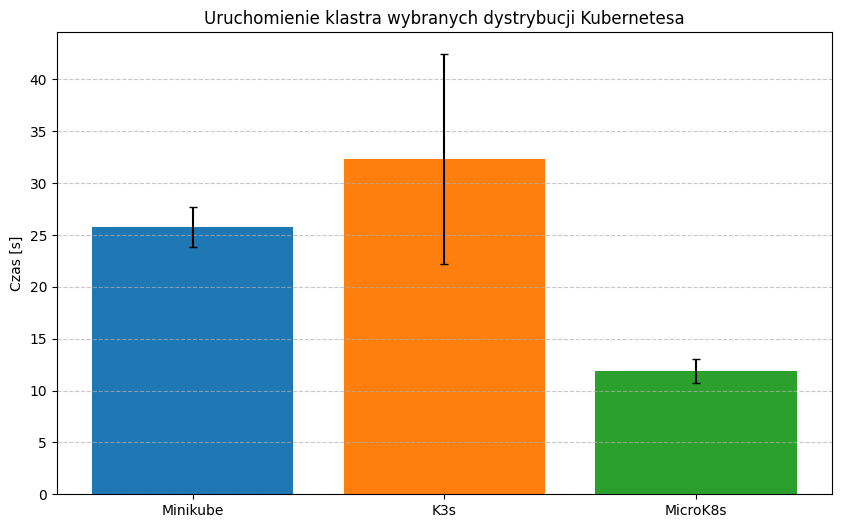

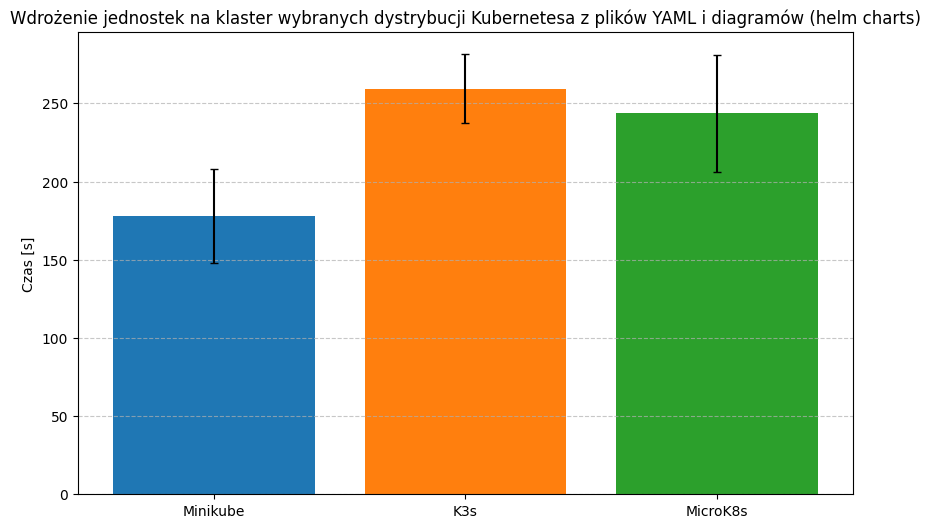

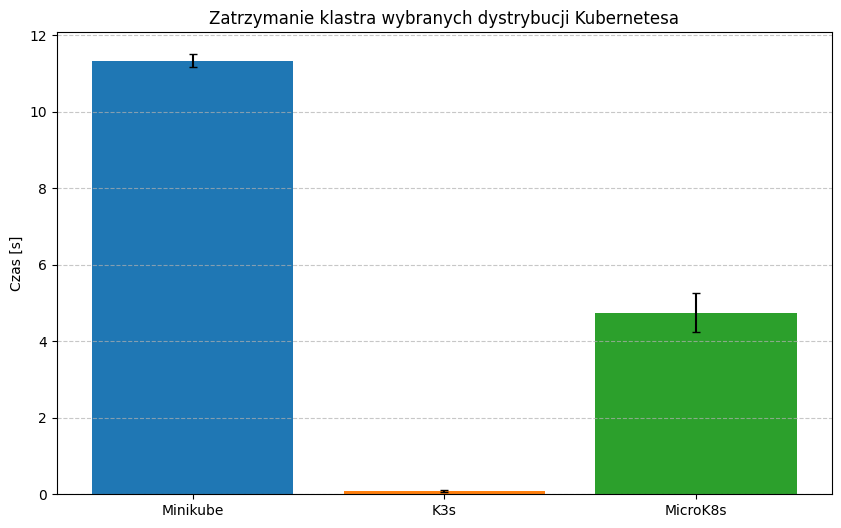

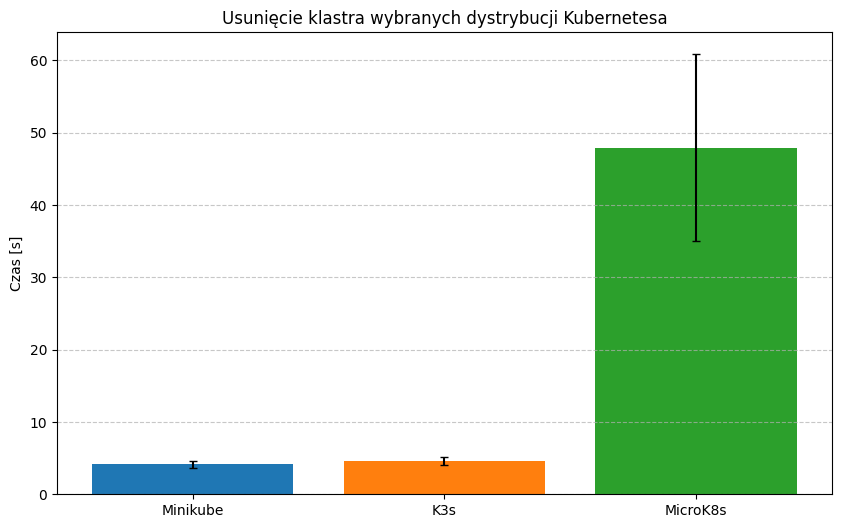

In [33]:
# zmienić to jak będzie reszta tych danych 
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
df = pd.read_csv("minikube_time2.csv")
df2 = pd.read_csv("k3s_time.csv")
df3 = pd.read_csv("microk8s_time.csv")

columns = {
    'start_time' : ["Uruchomienie klastra wybranych dystrybucji Kubernetesa", "Minikube", "K3s", "MicroK8s"],
    'deployment_time' : ["Wdrożenie jednostek na klaster wybranych dystrybucji Kubernetesa z plików YAML i diagramów (helm charts)", "Minikube", "K3s", "MicroK8s"],
    'stop_time' : ["Zatrzymanie klastra wybranych dystrybucji Kubernetesa", "Minikube", "K3s", "MicroK8s"], 
    'delete_time' : ["Usunięcie klastra wybranych dystrybucji Kubernetesa", "Minikube", "K3s", "MicroK8s"]}
for metric, title in columns.items():
    stdev1 = np.std(df[metric])
    stdev2 = np.std(df2[metric])
    stdev3 = np.std(df3[metric])
    plt.figure(figsize=(10, 6))
    x = df[metric].mean()
    plt.bar(title[1], df[metric].mean(), yerr=stdev1, capsize=3)
    plt.bar(title[2], df2[metric].mean(), yerr=stdev2, capsize=3)
    plt.bar(title[3], df3[metric].mean(), yerr=stdev3, capsize=3)
    # plt.errorbar(x, df[metric], yerr=stdev, capsize=3)
    plt.ylabel("Czas [s]")
    plt.title(title[0])
    # plt.xticks(x)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

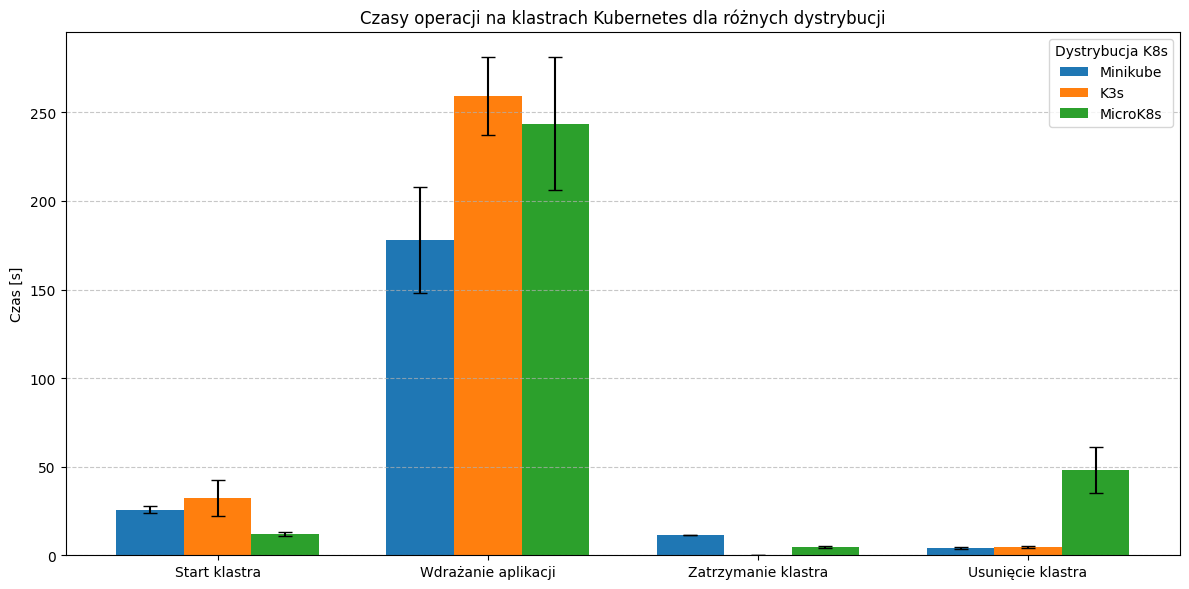

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data
df = pd.read_csv("minikube_time2.csv")
df2 = pd.read_csv("k3s_time.csv")
df3 = pd.read_csv("microk8s_time.csv")

# Metrics and labels
metrics = ['start_time', 'deployment_time', 'stop_time', 'delete_time']
group_labels = [
    "Start klastra",
    "Wdrażanie aplikacji",
    "Zatrzymanie klastra",
    "Usunięcie klastra"
]
distros = ['Minikube', 'K3s', 'MicroK8s']
colors = ['tab:blue', 'tab:orange', 'tab:green']

# Prepare data
means = []
stdevs = []

for metric in metrics:
    means.append([
        df[metric].mean(),
        df2[metric].mean(),
        df3[metric].mean()
    ])
    stdevs.append([
        np.std(df[metric]),
        np.std(df2[metric]),
        np.std(df3[metric])
    ])

# Plot setup
x = np.arange(len(metrics))  # 0, 1, 2, 3
width = 0.25

plt.figure(figsize=(12, 6))

# Plot bars per distribution
for i in range(3):  # 0 = Minikube, 1 = K3s, 2 = MicroK8s
    distro_means = [means[j][i] for j in range(4)]
    distro_stdevs = [stdevs[j][i] for j in range(4)]
    plt.bar(x + i*width, distro_means, width, yerr=distro_stdevs, capsize=5,
            label=distros[i], color=colors[i])

# Labeling and formatting
plt.xticks(x + width, group_labels)
plt.ylabel("Czas [s]")
plt.title("Czasy operacji na klastrach Kubernetes dla różnych dystrybucji")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title="Dystrybucja K8s")
plt.tight_layout()
plt.show()


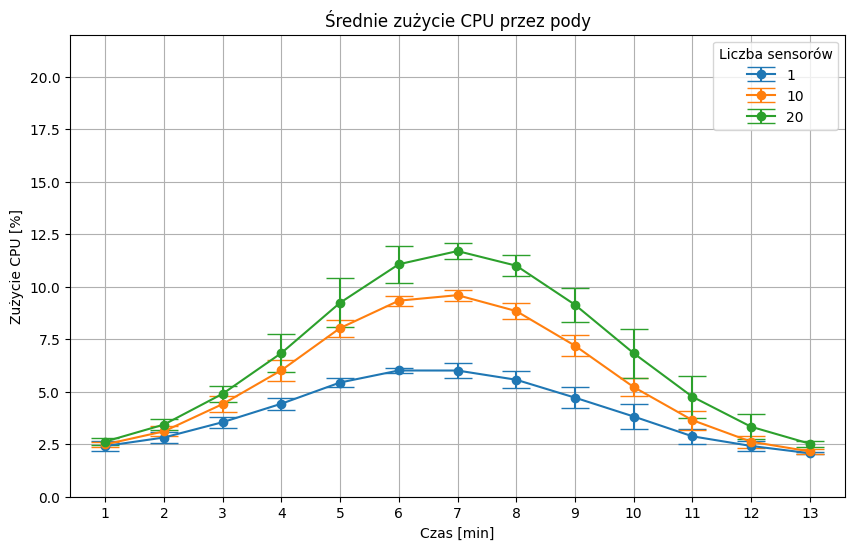

In [41]:
#minikube

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

cpu_1 = [2.6, 3.17, 4.58, 5.93, 8, 9.11, 9.22, 8.6, 7.01, 4.97, 3.66, 2.8, 2.43]
cpu_2 = [2.62, 3.50, 4.69, 6.61, 8.49, 9.64, 9.74, 8.42, 6.88, 4.79, 2.64, 2.69, 2.15]
cpu_3 = [2.52, 3.01, 4.3, 5.6, 7.8, 9.1, 9.71, 9.06, 7.45, 5.04, 3.8, 2.8, 2.2]
cpu_4 = [2.38, 3.01, 4.31, 6.08, 8.06, 9.48, 9.86, 9.12, 7.38, 5.65, 3.75, 2.69, 2.11]
cpu_5 = [2.48, 3.51, 4.42, 6.16, 8.15, 9.53, 9.79, 9.17, 7.47, 5.47, 3.9, 2.37, 2.09]
cpu_6 = [2.47, 3.12, 4.36, 6.10, 8.08, 9.48, 9.65, 8.69, 7.24, 5.21, 3.76, 2.87, 2.24]
cpu_7 = [2.62, 3.11, 5.17, 6.98, 8.64, 9.50, 9.13, 8.10, 5.90, 4.41, 3.01, 2.37, 2.01]
cpu_8 = [2.42, 3, 4.15, 5.80, 7.72, 9.12, 9.65, 8.95, 7.38, 5.45, 4.04, 2.03, 2.01]
cpu_9 = [2.48, 2.98, 4.41, 5.68, 8.18, 9.47, 9.86, 9.26, 7.57, 5.49, 3.84, 2.66, 2.12]
cpu_10 = [2.32, 2.73, 3.74, 5.28, 7.19, 8.92, 9.37, 9.04, 7.64, 5.74, 4.06, 2.91, 2.22]

cpu_1_1 = [2.47, 2.84, 3.58, 4.58, 5.56, 6.12, 6.15, 5.58, 4.63, 3.55, 2.9, 2.53, 2.16]
cpu_2_1 = [2.58, 2.86, 3.51, 4.14, 5.09, 5.73, 6.14, 5.89, 5.17, 4.15, 2.6, 2.3, 2.08]
cpu_3_1 = [2.18, 2.5, 3.13, 4.23, 5.27, 5.88, 5.17, 5.86, 5.05, 5.03, 3.18, 2.52, 2.03]
cpu_4_1 = [2.17, 2.56, 3.31, 4.05, 5.28, 5.92, 6.19, 5.73, 4.86, 3.86, 3.07, 2.57, 2.04]
cpu_5_1 = [2.52, 2.81, 3.51, 4.19, 5.21, 6.06, 6.47, 6.26, 5.5, 4.43, 3.47, 2.5, 2.15]
cpu_6_1 = [1.94, 2.49, 3.34, 4.26, 5.40, 5.97, 5.96, 5.24, 4.44, 3.54, 2.8, 2.49, 2.07]
cpu_7_1 = [2.54, 3.07, 3.81, 4.63, 5.65, 6.02, 5.85, 5.15, 4.09, 3.14, 2.45, 2.06, 2.01]
cpu_8_1 = [2.52, 2.86, 3.5, 4.58, 5.41, 6.10, 6.29, 5.79, 5.08, 4.08, 3.21, 2.86, 2.12]
cpu_9_1 = [2.76, 3.26, 4.01, 4.8, 5.80, 6.21, 6.10, 5.30, 4.46, 3.32, 2.65, 2.15, 2.04]
cpu_10_1 = [2.47, 2.95, 3.80, 4.83, 5.72, 6.10, 5.77, 4.9, 3.9, 3.1, 2.44, 2.19, 2.01]

cpu_1_20 = [2.64, 3.54, 5.13, 7.33, 9.78, 11.44, 11.68, 10.82, 8.69, 6.22, 4.02, 2.96, 2.33]
cpu_2_20 = [2.45, 3.5, 4.51, 7.15, 9.93, 11.33, 11.71, 10.38, 8.56, 5.74, 4.13, 2.81, 2.41]
cpu_3_20 = [2.73, 3.37, 5.14, 6.88, 9.33, 11.2, 11.88, 11.22, 8.86, 6.8, 4.73, 3.26, 2.5]
cpu_4_20 = [2.62, 3.47, 4.95, 7.18, 9.65, 11.32, 11.72, 10.50, 8.68, 6.22, 4.30, 3.07, 2.4]
cpu_5_20 = [2.77, 3.65, 5.16, 7.33, 9.82, 11.4, 11.7, 10.80, 8.68, 6.11, 4.30, 3.08, 2.59]
cpu_6_20 = [2.47, 3.13, 4.71, 6.35, 8.77, 11.11, 11.93, 11.56, 9.51, 7.5, 5, 3.48, 2.63]
cpu_7_20 = [2.52, 3.09, 4.33, 4.64, 6.23, 8.63, 10.62, 11.69, 11.09, 9.74, 7.37, 4.93, 2.81]
cpu_8_20 = [2.69, 3.42, 4.79, 6.81, 9.23, 11.22, 11.9, 11.33, 9.44, 6.97, 4.97, 3.32, 2.49]
cpu_9_20 = [2.49, 3.25, 4.66, 6.72, 9.21, 11.18, 11.9, 11.36, 9.54, 7.09, 4.9, 3.48, 2.69]
cpu_10_20 = [2.89, 3.94, 5.65, 8.03, 10.43, 11.87, 11.94, 10.35, 8.37, 5.94, 3.89, 2.93, 2.39]


df1 = pd.DataFrame({
    '1': [cpu_1[0], cpu_2[0], cpu_3[0], cpu_4[0], cpu_5[0], cpu_6[0], cpu_7[0], cpu_8[0], cpu_9[0], cpu_10[0]],
    '2': [cpu_1[1], cpu_2[1], cpu_3[1], cpu_4[1], cpu_5[1], cpu_6[1], cpu_7[1], cpu_8[1], cpu_9[1], cpu_10[1]],
    '3': [cpu_1[2], cpu_2[2], cpu_3[2], cpu_4[2], cpu_5[2], cpu_6[2], cpu_7[2], cpu_8[2], cpu_9[2], cpu_10[2]], 
    '4': [cpu_1[3], cpu_2[3], cpu_3[3], cpu_4[3], cpu_5[3], cpu_6[3], cpu_7[3], cpu_8[3], cpu_9[3], cpu_10[3]],
    '5': [cpu_1[4], cpu_2[4], cpu_3[4], cpu_4[4], cpu_5[4], cpu_6[4], cpu_7[4], cpu_8[4], cpu_9[4], cpu_10[4]],
    '6': [cpu_1[5], cpu_2[5], cpu_3[5], cpu_4[5], cpu_5[5], cpu_6[5], cpu_7[5], cpu_8[5], cpu_9[5], cpu_10[5]],
    '7': [cpu_1[6], cpu_2[6], cpu_3[6], cpu_4[6], cpu_5[6], cpu_6[6], cpu_7[6], cpu_8[6], cpu_9[6], cpu_10[6]],
    '8': [cpu_1[7], cpu_2[7], cpu_3[7], cpu_4[7], cpu_5[7], cpu_6[7], cpu_7[7], cpu_8[7], cpu_9[7], cpu_10[7]],
    '9': [cpu_1[8], cpu_2[8], cpu_3[8], cpu_4[8], cpu_5[8], cpu_6[8], cpu_7[8], cpu_8[8], cpu_9[8], cpu_10[8]],
    '10': [cpu_1[9], cpu_2[9], cpu_3[9], cpu_4[9], cpu_5[9], cpu_6[9], cpu_7[9], cpu_8[9], cpu_9[9], cpu_10[9]],
    '11': [cpu_1[10], cpu_2[10], cpu_3[10], cpu_4[10], cpu_5[10], cpu_6[10], cpu_7[10], cpu_8[10], cpu_9[10], cpu_10[10]],
    '12': [cpu_1[11], cpu_2[11], cpu_3[11], cpu_4[11], cpu_5[11], cpu_6[11], cpu_7[11], cpu_8[11], cpu_9[11], cpu_10[11]],
    '13': [cpu_1[12], cpu_2[12], cpu_3[12], cpu_4[12], cpu_5[12], cpu_6[12], cpu_7[12], cpu_8[12], cpu_9[12], cpu_10[12]]})

df2 = pd.DataFrame({
    '1' : [cpu_1_1[0], cpu_2_1[0], cpu_3_1[0], cpu_4_1[0], cpu_5_1[0], cpu_6_1[0], cpu_7_1[0], cpu_8_1[0], cpu_9_1[0], cpu_10_1[0]],
    '2' : [cpu_1_1[1], cpu_2_1[1], cpu_3_1[1], cpu_4_1[1], cpu_5_1[1], cpu_6_1[1], cpu_7_1[1], cpu_8_1[1], cpu_9_1[1], cpu_10_1[1]],
    '3' : [cpu_1_1[2], cpu_2_1[2], cpu_3_1[2], cpu_4_1[2], cpu_5_1[2], cpu_6_1[2], cpu_7_1[2], cpu_8_1[2], cpu_9_1[2], cpu_10_1[2]],
    '4' : [cpu_1_1[3], cpu_2_1[3], cpu_3_1[3], cpu_4_1[3], cpu_5_1[3], cpu_6_1[3], cpu_7_1[3], cpu_8_1[3], cpu_9_1[3], cpu_10_1[3]], 
    '5' : [cpu_1_1[4], cpu_2_1[4], cpu_3_1[4], cpu_4_1[4], cpu_5_1[4], cpu_6_1[4], cpu_7_1[4], cpu_8_1[4], cpu_9_1[4], cpu_10_1[4]],
    '6' : [cpu_1_1[5], cpu_2_1[5], cpu_3_1[5], cpu_4_1[5], cpu_5_1[5], cpu_6_1[5], cpu_7_1[5], cpu_8_1[5], cpu_9_1[5], cpu_10_1[5]],
    '7' : [cpu_1_1[6], cpu_2_1[6], cpu_3_1[6], cpu_4_1[6], cpu_5_1[6], cpu_6_1[6], cpu_7_1[6], cpu_8_1[6], cpu_9_1[6], cpu_10_1[6]],
    '8' : [cpu_1_1[7], cpu_2_1[7], cpu_3_1[7], cpu_4_1[7], cpu_5_1[7], cpu_6_1[7], cpu_7_1[7], cpu_8_1[7], cpu_9_1[7], cpu_10_1[7]],
    '9' : [cpu_1_1[8], cpu_2_1[8], cpu_3_1[8], cpu_4_1[8], cpu_5_1[8], cpu_6_1[8], cpu_7_1[8], cpu_8_1[8], cpu_9_1[8], cpu_10_1[8]],
    '10': [cpu_1_1[9], cpu_2_1[9], cpu_3_1[9], cpu_4_1[9], cpu_5_1[9], cpu_6_1[9], cpu_7_1[9], cpu_8_1[9], cpu_9_1[9], cpu_10_1[9]],
    '11': [cpu_1_1[10], cpu_2_1[10], cpu_3_1[10], cpu_4_1[10], cpu_5_1[10], cpu_6_1[10], cpu_7_1[10], cpu_8_1[10], cpu_9_1[10], cpu_10_1[10]],
    '12': [cpu_1_1[11], cpu_2_1[11], cpu_3_1[11], cpu_4_1[11], cpu_5_1[11], cpu_6_1[11], cpu_7_1[11], cpu_8_1[11], cpu_9_1[11], cpu_10_1[11]],
    '13': [cpu_1_1[12], cpu_2_1[12], cpu_3_1[12], cpu_4_1[12], cpu_5_1[12], cpu_6_1[12], cpu_7_1[12], cpu_8_1[12], cpu_9_1[12], cpu_10_1[12]]})

df3 = pd.DataFrame({
    '1' : [cpu_1_20[0], cpu_2_20[0], cpu_3_20[0], cpu_4_20[0], cpu_5_20[0], cpu_6_20[0], cpu_7_20[0], cpu_8_20[0], cpu_9_20[0], cpu_10_20[0]],
    '2' : [cpu_1_20[1], cpu_2_20[1], cpu_3_20[1], cpu_4_20[1], cpu_5_20[1], cpu_6_20[1], cpu_7_20[1], cpu_8_20[1], cpu_9_20[1], cpu_10_20[1]],
    '3' : [cpu_1_20[2], cpu_2_20[2], cpu_3_20[2], cpu_4_20[2], cpu_5_20[2], cpu_6_20[2], cpu_7_20[2], cpu_8_20[2], cpu_9_20[2], cpu_10_20[2]],
    '4' : [cpu_1_20[3], cpu_2_20[3], cpu_3_20[3], cpu_4_20[3], cpu_5_20[3], cpu_6_20[3], cpu_7_20[3], cpu_8_20[3], cpu_9_20[3], cpu_10_20[3]],
    '5' : [cpu_1_20[4], cpu_2_20[4], cpu_3_20[4], cpu_4_20[4], cpu_5_20[4], cpu_6_20[4], cpu_7_20[4], cpu_8_20[4], cpu_9_20[4], cpu_10_20[4]],
    '6' : [cpu_1_20[5], cpu_2_20[5], cpu_3_20[5], cpu_4_20[5], cpu_5_20[5], cpu_6_20[5], cpu_7_20[5], cpu_8_20[5], cpu_9_20[5], cpu_10_20[5]],
    '7' : [cpu_1_20[6], cpu_2_20[6], cpu_3_20[6], cpu_4_20[6], cpu_5_20[6], cpu_6_20[6], cpu_7_20[6], cpu_8_20[6], cpu_9_20[6], cpu_10_20[6]],
    '8' : [cpu_1_20[7], cpu_2_20[7], cpu_3_20[7], cpu_4_20[7], cpu_5_20[7], cpu_6_20[7], cpu_7_20[7], cpu_8_20[7], cpu_9_20[7], cpu_10_20[7]],
    '9' : [cpu_1_20[8], cpu_2_20[8], cpu_3_20[8], cpu_4_20[8], cpu_5_20[8], cpu_6_20[8], cpu_7_20[8], cpu_8_20[8], cpu_9_20[8], cpu_10_20[8]],
    '10': [cpu_1_20[9], cpu_2_20[9], cpu_3_20[9], cpu_4_20[9], cpu_5_20[9], cpu_6_20[9], cpu_7_20[9], cpu_8_20[9], cpu_9_20[9], cpu_10_20[9]],
    '11': [cpu_1_20[10], cpu_2_20[10], cpu_3_20[10], cpu_4_20[10], cpu_5_20[10], cpu_6_20[10], cpu_7_20[10], cpu_8_20[10], cpu_9_20[10], cpu_10_20[10]],
    '12': [cpu_1_20[11], cpu_2_20[11], cpu_3_20[11], cpu_4_20[11], cpu_5_20[11], cpu_6_20[11], cpu_7_20[11], cpu_8_20[11], cpu_9_20[11], cpu_10_20[11]],
    '13': [cpu_1_20[12], cpu_2_20[12], cpu_3_20[12], cpu_4_20[12], cpu_5_20[12], cpu_6_20[12], cpu_7_20[12], cpu_8_20[12], cpu_9_20[12], cpu_10_20[12]]})

cols = ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13']
means1 = []
std1 = []

means2 = []
std2 = []

means3 = []
std3 = []
for col in cols:
    means2.append(df2[col].mean())
    std2.append(df2[col].std()) 

for col in cols:
    means3.append(df3[col].mean())
    std3.append(df3[col].std())
for col in cols:
    means1.append(df1[col].mean())
    std1.append(df1[col].std())
plt.figure(figsize=(10, 6))
plt.errorbar(cols, means2, yerr=std2, fmt='o-', capsize=10)
plt.errorbar(cols, means1, yerr=std1, fmt='o-', capsize=10)
plt.errorbar(cols, means3, yerr=std3, fmt='o-', capsize=10)
plt.legend(['1', '10', '20'], title="Liczba sensorów")
plt.title("Średnie zużycie CPU przez pody")
plt.ylim(0, 22)
plt.xlabel("Czas [min]")
plt.ylabel("Zużycie CPU [%]")
plt.grid()
plt.show()

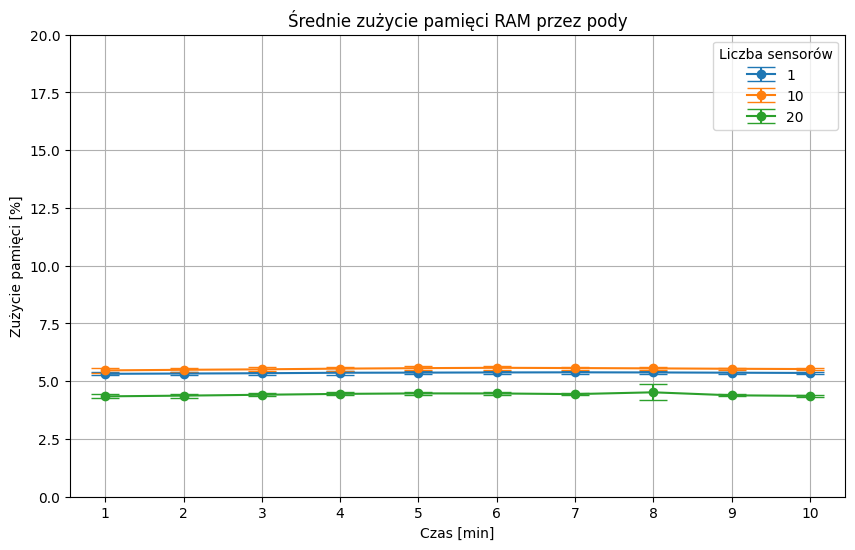

In [ ]:

#minikube
mem_1 = [5.25, 5.29, 5.35, 5.41, 5.45, 5.47, 5.48, 5.47, 5.45, 5.44]
mem_2 = [5.41, 5.41, 5.41, 5.43, 5.44, 5.45, 5.47, 5.47, 5.48, 5.46]
mem_3 = [5.4, 5.44, 5.44, 5.46, 5.48, 5.52, 5.52, 5.52, 5.51, 5.50]
mem_4 = [5.48, 5.49, 5.51, 5.54, 5.55, 5.55, 5.54, 5.52, 5.50, 5.49]
mem_5 = [5.50, 5.52, 5.53, 5.54, 5.55, 5.56, 5.55, 5.53, 5.52, 5.51]
mem_6 = [5.50, 5.52, 5.54, 5.58, 5.60, 5.61, 5.60, 5.59, 5.57, 5.57]
mem_7 = [5.55, 5.56, 5.57, 5.60, 5.62, 5.64, 5.62, 5.60, 5.58, 5.57]
mem_8 = [5.52, 5.53, 5.57, 5.60, 5.63, 5.66, 5.63, 5.60, 5.57, 5.56]
mem_9 = [5.54, 5.58, 5.61, 5.63, 5.67, 5.68, 5.65, 5.63, 5.61, 5.58]
mem_10 = [5.54, 5.60, 5.62, 5.66, 5.67, 5.67, 5.64, 5.63, 5.60, 5.59]


mem_1_1 = [5.25, 5.25, 5.26, 5.28, 5.29, 5.29, 5.30, 5.30, 5.30, 5.29]
mem_2_1 = [5.25, 5.25, 5.27, 5.29, 5.31, 5.33, 5.35, 5.36, 5.35, 5.33]
mem_3_1 = [5.28, 5.29, 5.30, 5.31, 5.32, 5.32, 5.33, 5.33, 5.32, 5.32]
mem_4_1 = [5.24, 5.25, 5.26, 5.27, 5.29, 5.31, 5.32, 5.33, 5.32, 5.32]
mem_5_1 = [5.30, 5.30, 5.31, 5.32, 5.34, 5.35, 5.36, 5.36, 5.35, 5.34]
mem_6_1 = [5.33, 5.36, 5.38, 5.39, 5.41, 5.42, 5.42, 5.42, 5.39, 5.37]
mem_7_1 = [5.42, 5.45, 5.46, 5.54, 5.44, 5.42, 5.42, 5.40, 5.39, 5.39]
mem_8_1 = [5.36, 5.38, 5.40, 5.42, 5.44, 5.46, 5.44, 5.41, 5.40, 5.38]
mem_9_1 = [5.39, 5.40, 5.42, 5.43, 5.45, 5.46, 5.46, 5.44, 5.42, 5.40]
mem_10_1 = [5.38, 5.40, 5.40, 5.42, 5.43, 5.44, 5.45, 5.45, 5.45, 5.44]


mem_1_20 = [4.11, 4.16, 4.25, 4.32, 4.35, 4.37, 4.34, 4.31, 4.28, 4.27]
mem_2_20 = [4.28, 4.29, 4.33, 4.36, 4.39, 4.41, 4.41, 4.48, 4.45, 4.38]
mem_3_20 = [4.37, 4.40, 4.42, 4.44, 4.47, 4.46, 4.42, 4.40, 4.37, 4.35]
mem_4_20 = [4.38, 4.42, 4.45, 4.49, 4.51, 4.51, 4.48, 4.45, 4.42, 4.40]
mem_5_20 = [4.40, 4.43, 4.46, 4.48, 4.51, 4.49, 4.46, 4.42, 4.39, 4.37]
mem_6_20 = [4.39, 4.43, 4.48, 4.52, 4.56, 4.57, 4.52, 5.48, 4.44, 4.39]
mem_7_20 = [4.38, 4.41, 4.45, 4.48, 4.49, 4.48, 4.45, 4.42, 4.39, 4.36]
mem_8_20 = [4.38, 4.40, 4.43, 4.48, 4.48, 4.47, 4.44, 4.41, 4.38, 4.36]
mem_9_20 = [4.37, 4.40, 4.43, 4.48, 4.50, 4.49, 4.46, 4.42, 4.39, 4.37]
mem_10_20 = [4.39, 4.42, 4.44, 4.47, 4.47, 4.46, 4.44, 4.41, 4.39, 4.39]


df1= pd.DataFrame({
    '1' : [mem_1[0], mem_2[0], mem_3[0], mem_4[0], mem_5[0], mem_6[0], mem_7[0], mem_8[0], mem_9[0], mem_10[0]],
    '2' : [mem_1[1], mem_2[1], mem_3[1], mem_4[1], mem_5[1], mem_6[1], mem_7[1], mem_8[1], mem_9[1], mem_10[1]],
    '3' : [mem_1[2], mem_2[2], mem_3[2], mem_4[2], mem_5[2], mem_6[2], mem_7[2], mem_8[2], mem_9[2], mem_10[2]],
    '4' : [mem_1[3], mem_2[3], mem_3[3], mem_4[3], mem_5[3], mem_6[3], mem_7[3], mem_8[3], mem_9[3], mem_10[3]],
    '5' : [mem_1[4], mem_2[4], mem_3[4], mem_4[4], mem_5[4], mem_6[4], mem_7[4], mem_8[4], mem_9[4], mem_10[4]],
    '6' : [mem_1[5], mem_2[5], mem_3[5], mem_4[5], mem_5[5], mem_6[5], mem_7[5], mem_8[5], mem_9[5], mem_10[5]],
    '7' : [mem_1[6], mem_2[6], mem_3[6], mem_4[6], mem_5[6], mem_6[6], mem_7[6], mem_8[6], mem_9[6], mem_10[6]],
    '8' : [mem_1[7], mem_2[7], mem_3[7], mem_4[7], mem_5[7], mem_6[7], mem_7[7], mem_8[7], mem_9[7], mem_10[7]],
    '9' : [mem_1[8], mem_2[8], mem_3[8], mem_4[8], mem_5[8], mem_6[8], mem_7[8], mem_8[8], mem_9[8], mem_10[8]],
    '10': [mem_1[9], mem_2[9], mem_3[9], mem_4[9], mem_5[9], mem_6[9], mem_7[9], mem_8[9], mem_9[9], mem_10[9]]})

df2 = pd.DataFrame({
    '1' : [mem_1_1[0], mem_2_1[0], mem_3_1[0], mem_4_1[0], mem_5_1[0], mem_6_1[0], mem_7_1[0], mem_8_1[0], mem_9_1[0], mem_10_1[0]],
    '2' : [mem_1_1[1], mem_2_1[1], mem_3_1[1], mem_4_1[1], mem_5_1[1], mem_6_1[1], mem_7_1[1], mem_8_1[1], mem_9_1[1], mem_10_1[1]],
    '3' : [mem_1_1[2], mem_2_1[2], mem_3_1[2], mem_4_1[2], mem_5_1[2], mem_6_1[2], mem_7_1[2], mem_8_1[2], mem_9_1[2], mem_10_1[2]],
    '4' : [mem_1_1[3], mem_2_1[3], mem_3_1[3], mem_4_1[3], mem_5_1[3], mem_6_1[3], mem_7_1[3], mem_8_1[3], mem_9_1[3], mem_10_1[3]],
    '5' : [mem_1_1[4], mem_2_1[4], mem_3_1[4], mem_4_1[4], mem_5_1[4], mem_6_1[4], mem_7_1[4], mem_8_1[4], mem_9_1[4], mem_10_1[4]],
    '6' : [mem_1_1[5], mem_2_1[5], mem_3_1[5], mem_4_1[5], mem_5_1[5], mem_6_1[5], mem_7_1[5], mem_8_1[5], mem_9_1[5], mem_10_1[5]],
    '7' : [mem_1_1[6], mem_2_1[6], mem_3_1[6], mem_4_1[6], mem_5_1[6], mem_6_1[6], mem_7_1[6], mem_8_1[6], mem_9_1[6], mem_10_1[6]],
    '8' : [mem_1_1[7], mem_2_1[7], mem_3_1[7], mem_4_1[7], mem_5_1[7], mem_6_1[7], mem_7_1[7], mem_8_1[7], mem_9_1[7], mem_10_1[7]],
    '9' : [mem_1_1[8], mem_2_1[8], mem_3_1[8], mem_4_1[8], mem_5_1[8], mem_6_1[8], mem_7_1[8], mem_8_1[8], mem_9_1[8], mem_10_1[8]],
    '10': [mem_1_1[9], mem_2_1[9], mem_3_1[9], mem_4_1[9], mem_5_1[9], mem_6_1[9], mem_7_1[9], mem_8_1[9], mem_9_1[9], mem_10_1[9]]})

df3 = pd.DataFrame({
    '1' : [mem_1_20[0], mem_2_20[0], mem_3_20[0], mem_4_20[0], mem_5_20[0], mem_6_20[0], mem_7_20[0], mem_8_20[0], mem_9_20[0], mem_10_20[0]],
    '2' : [mem_1_20[1], mem_2_20[1], mem_3_20[1], mem_4_20[1], mem_5_20[1], mem_6_20[1], mem_7_20[1], mem_8_20[1], mem_9_20[1], mem_10_20[1]],
    '3' : [mem_1_20[2], mem_2_20[2], mem_3_20[2], mem_4_20[2], mem_5_20[2], mem_6_20[2], mem_7_20[2], mem_8_20[2], mem_9_20[2], mem_10_20[2]],
    '4' : [mem_1_20[3], mem_2_20[3], mem_3_20[3], mem_4_20[3], mem_5_20[3], mem_6_20[3], mem_7_20[3], mem_8_20[3], mem_9_20[3], mem_10_20[3]],
    '5' : [mem_1_20[4], mem_2_20[4], mem_3_20[4], mem_4_20[4], mem_5_20[4], mem_6_20[4], mem_7_20[4], mem_8_20[4], mem_9_20[4], mem_10_20[4]],
    '6' : [mem_1_20[5], mem_2_20[5], mem_3_20[5], mem_4_20[5], mem_5_20[5], mem_6_20[5], mem_7_20[5], mem_8_20[5], mem_9_20[5], mem_10_20[5]],
    '7' : [mem_1_20[6], mem_2_20[6], mem_3_20[6], mem_4_20[6], mem_5_20[6], mem_6_20[6], mem_7_20[6], mem_8_20[6], mem_9_20[6], mem_10_20[6]],
    '8' : [mem_1_20[7], mem_2_20[7], mem_3_20[7], mem_4_20[7], mem_5_20[7], mem_6_20[7], mem_7_20[7], mem_8_20[7], mem_9_20[7], mem_10_20[7]],
    '9' : [mem_1_20[8], mem_2_20[8], mem_3_20[8], mem_4_20[8], mem_5_20[8], mem_6_20[8], mem_7_20[8], mem_8_20[8], mem_9_20[8], mem_10_20[8]],
    '10': [mem_1_20[9], mem_2_20[9], mem_3_20[9], mem_4_20[9], mem_5_20[9], mem_6_20[9], mem_7_20[9], mem_8_20[9], mem_9_20[9], mem_10_20[9]]})

cols = ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10']
means1 = []
std1 = []

means2 = []
std2 = []

means3 = []
std3 = []

for col in cols:
    means1.append(df1[col].mean())
    std1.append(df1[col].std())


for col in cols:
    means2.append(df2[col].mean())
    std2.append(df2[col].std())


for col in cols:
    means3.append(df3[col].mean())
    std3.append(df3[col].std())
plt.figure(figsize=(10, 6))
plt.errorbar(cols, means2, yerr=std2, fmt='o-', capsize=10)
plt.errorbar(cols, means1, yerr=std1, fmt='o-', capsize=10)
plt.errorbar(cols, means3, yerr=std3, fmt='o-', capsize=10)
plt.legend(['1', '10', '20'], title="Liczba sensorów")
plt.title("Średnie zużycie pamięci RAM przez pody")
plt.ylim(0, 20)
plt.xlabel("Czas [min]")
plt.ylabel("Zużycie pamięci [%]")
plt.grid()
plt.show()



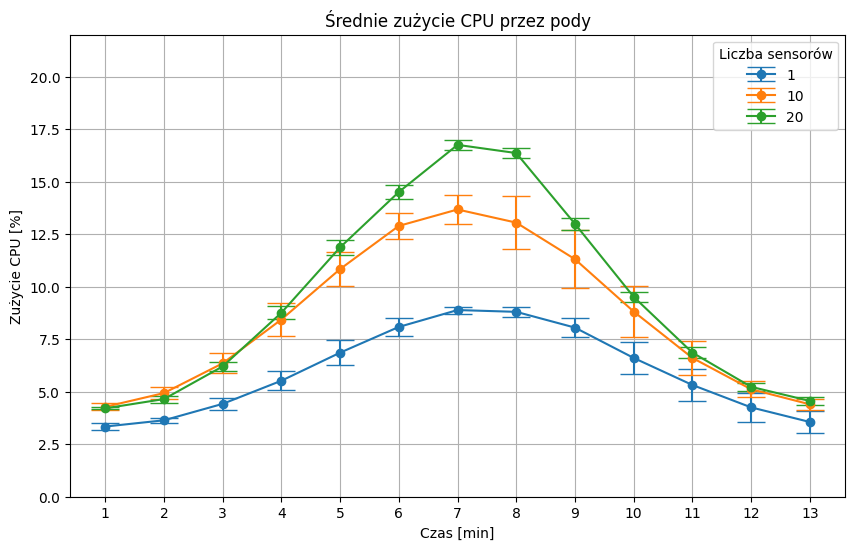

In [46]:
#k3s

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

cpu_1_1 = [3.39, 3.49, 3.89, 4.89, 6.17, 7.4, 8.7, 9.14, 8.63, 7.42, 6.14, 4.72, 3.8, 3.3]
cpu_2_1 = [3.22, 3.43, 4.75, 6.08, 7.83, 8.7, 9.15, 8.5, 7.46, 5.5, 3.98, 2.8, 2.2, 2.3]
cpu_3_1 = [2.98, 3.68, 4.64, 5.58, 7.2, 8.30, 9.09, 8.92, 8, 6.5, 5.44, 4.4, 3.7, 3.4]
cpu_4_1 = [3.4, 3.65, 4.8, 6.29, 7.45, 8.45, 8.89, 8.55, 7.45, 6.01, 4.77, 3.9, 3.38]
cpu_5_1 = [3.31, 3.57, 4.3, 5.26, 6.64, 8.01, 8.82, 8.85, 8.76, 7.85, 6.70, 5.25, 4.1, 3.4]
cpu_6_1 = [3.3, 3.69, 4.47, 5.6, 7.31, 8.34, 8.95, 8.79, 7.99, 6.5, 5.07, 4.43, 3.74, 3.54]
cpu_7_1 = [3.5, 3.69, 4.12, 5.2, 6.3, 7.85, 8.87, 9, 8.12, 6.97, 5.24, 4.29, 3.44, 3.4]
cpu_8_1 = [3.29, 3.80, 4.68, 5.91, 7.10, 8.32, 8.86, 8.41, 7.53, 5.48, 4.77, 3.48, 3.44]
cpu_9_1 = [3.41, 3.62, 4.3, 5.3, 6.47, 7.96, 8.97, 9.09, 8.30, 6.98, 5.59, 4.7, 4, 3.66]
cpu_10_1 = [3.62, 3.77, 4.27, 5.13, 6.13, 7.52, 8.59, 8.79, 8.29, 6.88, 5.51, 4.58, 3.79]


cpu_1 = [4.48, 4.99, 6.29, 8.30, 11.4, 13.7, 14.7, 14.18, 12.25, 9.47, 7, 5.27, 4.4, 4.0]
cpu_2 = [4.27, 4.70, 6.19, 8.25, 10.9, 13.41, 14.63, 14.45, 13.17, 10.52, 7.81, 5.5, 4.9]
cpu_3 = [4.6, 5.6, 7.08, 9.88, 12.04, 13.08, 14.18, 12.92, 10.52, 8.36, 6.28, 4.94, 4.2]
cpu_4 = [4.23, 4.96, 6.45, 8.69, 11.31, 13.51, 14, 13.92, 10.84, 8.6, 6.18, 4.74, 4.04]
cpu_5 = [4.08, 4.82, 6.01, 8.51, 10.6, 13.03, 13.8, 13.09, 11.56, 9.04, 6.45, 5.16, 4.6]
cpu_6 = [4.09, 4.7, 5.9, 7.48, 9.92, 12.3, 13.16, 13.51, 12.09, 9.27, 6.97, 5.55, 4.4]
cpu_7 = [4.37, 5.23, 7.20, 9.57, 11.95, 13.37, 12.65, 10.04, 8.02, 5.88, 4.87, 4.3, 4.3]
cpu_8 = [4.24, 4.79, 6.16, 8.13, 10.16, 12.17, 13.6, 13.36, 11.8, 9.45, 7.11, 5.13, 4.5]
cpu_9 = [4.3, 4.71, 5.79, 7.5, 9.76, 11.9, 13.03, 12.98, 11.9, 9.3, 7.1, 5.4, 4.6, 4.1]
cpu_10 = [4.14, 4.86, 6.46, 8.08, 10.37, 12.49, 13.03, 12.07, 10.96, 8.29, 6.33, 5.19, 4.06]


cpu_1_20 = [4.27, 4.63, 6.12, 8.74, 11.93, 14.42, 16.81, 16.68, 13.06, 9.49, 6.82, 5.21, 4.56, 4.12]
cpu_2_20 = [4.19, 4.51, 6.11, 8.35, 11.38, 14.28, 16.62, 16.18, 12.72, 9.37, 6.71, 5.19, 4.46, 4.23]
cpu_3_20 = [4.14, 4.79, 6.35, 9.03, 12.14, 14.75, 16.91, 16.53, 13.19, 9.68, 6.99, 5.38, 4.78, 4.26]
cpu_4_20 = [4.21, 4.64, 6.07, 8.55, 11.81, 14.34, 16.59, 16.12, 12.76, 9.35, 6.66, 5.05, 4.37, 4.13]
cpu_5_20 = [4.26, 4.82, 6.39, 9.08, 12.22, 14.82, 17.03, 16.42, 13.22, 9.72, 7.08, 5.39, 4.74, 4.29]
cpu_6_20 = [4.15, 4.41, 5.93, 8.40, 11.42, 14.18, 16.56, 16.20, 12.71, 9.26, 6.72, 5.17, 4.47, 4.16]
cpu_7_20 = [4.23, 4.86, 6.46, 9.14, 12.26, 14.95, 17.02, 16.67, 13.34, 9.85, 7.25, 5.45, 4.76, 4.35]
cpu_8_20 = [4.18, 4.52, 6.09, 8.62, 11.71, 14.27, 16.58, 16.15, 12.88, 9.40, 6.63, 5.07, 4.36, 4.04]
cpu_9_20 = [4.29, 4.85, 6.51, 9.16, 12.31, 14.98, 17.07, 16.65, 13.39, 9.89, 7.26, 5.48, 4.81, 4.32]
cpu_10_20 = [4.17, 4.47, 6.03, 8.53, 11.56, 14.11, 16.36, 16.05, 12.67, 9.17, 6.50, 4.94, 4.31, 4.07]





df2 = pd.DataFrame({
    '1': [cpu_1[0], cpu_2[0], cpu_3[0], cpu_4[0], cpu_5[0], cpu_6[0], cpu_7[0], cpu_8[0], cpu_9[0], cpu_10[0]],
    '2': [cpu_1[1], cpu_2[1], cpu_3[1], cpu_4[1], cpu_5[1], cpu_6[1], cpu_7[1], cpu_8[1], cpu_9[1], cpu_10[1]],
    '3': [cpu_1[2], cpu_2[2], cpu_3[2], cpu_4[2], cpu_5[2], cpu_6[2], cpu_7[2], cpu_8[2], cpu_9[2], cpu_10[2]], 
    '4': [cpu_1[3], cpu_2[3], cpu_3[3], cpu_4[3], cpu_5[3], cpu_6[3], cpu_7[3], cpu_8[3], cpu_9[3], cpu_10[3]],
    '5': [cpu_1[4], cpu_2[4], cpu_3[4], cpu_4[4], cpu_5[4], cpu_6[4], cpu_7[4], cpu_8[4], cpu_9[4], cpu_10[4]],
    '6': [cpu_1[5], cpu_2[5], cpu_3[5], cpu_4[5], cpu_5[5], cpu_6[5], cpu_7[5], cpu_8[5], cpu_9[5], cpu_10[5]],
    '7': [cpu_1[6], cpu_2[6], cpu_3[6], cpu_4[6], cpu_5[6], cpu_6[6], cpu_7[6], cpu_8[6], cpu_9[6], cpu_10[6]],
    '8': [cpu_1[7], cpu_2[7], cpu_3[7], cpu_4[7], cpu_5[7], cpu_6[7], cpu_7[7], cpu_8[7], cpu_9[7], cpu_10[7]],
    '9': [cpu_1[8], cpu_2[8], cpu_3[8], cpu_4[8], cpu_5[8], cpu_6[8], cpu_7[8], cpu_8[8], cpu_9[8], cpu_10[8]],
    '10': [cpu_1[9], cpu_2[9], cpu_3[9], cpu_4[9], cpu_5[9], cpu_6[9], cpu_7[9], cpu_8[9], cpu_9[9], cpu_10[9]], 
    '11': [cpu_1[10], cpu_2[10], cpu_3[10], cpu_4[10], cpu_5[10], cpu_6[10], cpu_7[10], cpu_8[10], cpu_9[10], cpu_10[10]],
    '12': [cpu_1[11], cpu_2[11], cpu_3[11], cpu_4[11], cpu_5[11], cpu_6[11], cpu_7[11], cpu_8[11], cpu_9[11], cpu_10[11]],
    '13': [cpu_1[12], cpu_2[12], cpu_3[12], cpu_4[12], cpu_5[12], cpu_6[12], cpu_7[12], cpu_8[12], cpu_9[12], cpu_10[12]]},
    )

df1 = pd.DataFrame({
    '1' : [cpu_1_1[0], cpu_2_1[0], cpu_3_1[0], cpu_4_1[0], cpu_5_1[0], cpu_6_1[0], cpu_7_1[0], cpu_8_1[0], cpu_9_1[0], cpu_10_1[0]],
    '2' : [cpu_1_1[1], cpu_2_1[1], cpu_3_1[1], cpu_4_1[1], cpu_5_1[1], cpu_6_1[1], cpu_7_1[1], cpu_8_1[1], cpu_9_1[1], cpu_10_1[1]],
    '3' : [cpu_1_1[2], cpu_2_1[2], cpu_3_1[2], cpu_4_1[2], cpu_5_1[2], cpu_6_1[2], cpu_7_1[2], cpu_8_1[2], cpu_9_1[2], cpu_10_1[2]],
    '4' : [cpu_1_1[3], cpu_2_1[3], cpu_3_1[3], cpu_4_1[3], cpu_5_1[3], cpu_6_1[3], cpu_7_1[3], cpu_8_1[3], cpu_9_1[3], cpu_10_1[3]], 
    '5' : [cpu_1_1[4], cpu_2_1[4], cpu_3_1[4], cpu_4_1[4], cpu_5_1[4], cpu_6_1[4], cpu_7_1[4], cpu_8_1[4], cpu_9_1[4], cpu_10_1[4]],
    '6' : [cpu_1_1[5], cpu_2_1[5], cpu_3_1[5], cpu_4_1[5], cpu_5_1[5], cpu_6_1[5], cpu_7_1[5], cpu_8_1[5], cpu_9_1[5], cpu_10_1[5]],
    '7' : [cpu_1_1[6], cpu_2_1[6], cpu_3_1[6], cpu_4_1[6], cpu_5_1[6], cpu_6_1[6], cpu_7_1[6], cpu_8_1[6], cpu_9_1[6], cpu_10_1[6]],
    '8' : [cpu_1_1[7], cpu_2_1[7], cpu_3_1[7], cpu_4_1[7], cpu_5_1[7], cpu_6_1[7], cpu_7_1[7], cpu_8_1[7], cpu_9_1[7], cpu_10_1[7]],
    '9' : [cpu_1_1[8], cpu_2_1[8], cpu_3_1[8], cpu_4_1[8], cpu_5_1[8], cpu_6_1[8], cpu_7_1[8], cpu_8_1[8], cpu_9_1[8], cpu_10_1[8]],
    '10': [cpu_1_1[9], cpu_2_1[9], cpu_3_1[9], cpu_4_1[9], cpu_5_1[9], cpu_6_1[9], cpu_7_1[9], cpu_8_1[9], cpu_9_1[9], cpu_10_1[9]],
    '11': [cpu_1_1[10], cpu_2_1[10], cpu_3_1[10], cpu_4_1[10], cpu_5_1[10], cpu_6_1[10], cpu_7_1[10], cpu_8_1[10], cpu_9_1[10], cpu_10_1[10]],
    '12': [cpu_1_1[11], cpu_2_1[11], cpu_3_1[11], cpu_4_1[11], cpu_5_1[11], cpu_6_1[11], cpu_7_1[11], cpu_8_1[11], cpu_9_1[11], cpu_10_1[11]],
    '13': [cpu_1_1[12], cpu_2_1[12], cpu_3_1[12], cpu_4_1[12], cpu_5_1[12], cpu_6_1[12], cpu_7_1[12], cpu_8_1[12], cpu_9_1[12], cpu_10_1[12]]})

df3 = pd.DataFrame({
    '1' : [cpu_1_20[0], cpu_2_20[0], cpu_3_20[0], cpu_4_20[0], cpu_5_20[0], cpu_6_20[0], cpu_7_20[0], cpu_8_20[0], cpu_9_20[0], cpu_10_20[0]],
    '2' : [cpu_1_20[1], cpu_2_20[1], cpu_3_20[1], cpu_4_20[1], cpu_5_20[1], cpu_6_20[1], cpu_7_20[1], cpu_8_20[1], cpu_9_20[1], cpu_10_20[1]],
    '3' : [cpu_1_20[2], cpu_2_20[2], cpu_3_20[2], cpu_4_20[2], cpu_5_20[2], cpu_6_20[2], cpu_7_20[2], cpu_8_20[2], cpu_9_20[2], cpu_10_20[2]],
    '4' : [cpu_1_20[3], cpu_2_20[3], cpu_3_20[3], cpu_4_20[3], cpu_5_20[3], cpu_6_20[3], cpu_7_20[3], cpu_8_20[3], cpu_9_20[3], cpu_10_20[3]],
    '5' : [cpu_1_20[4], cpu_2_20[4], cpu_3_20[4], cpu_4_20[4], cpu_5_20[4], cpu_6_20[4], cpu_7_20[4], cpu_8_20[4], cpu_9_20[4], cpu_10_20[4]],
    '6' : [cpu_1_20[5], cpu_2_20[5], cpu_3_20[5], cpu_4_20[5], cpu_5_20[5], cpu_6_20[5], cpu_7_20[5], cpu_8_20[5], cpu_9_20[5], cpu_10_20[5]],
    '7' : [cpu_1_20[6], cpu_2_20[6], cpu_3_20[6], cpu_4_20[6], cpu_5_20[6], cpu_6_20[6], cpu_7_20[6], cpu_8_20[6], cpu_9_20[6], cpu_10_20[6]],
    '8' : [cpu_1_20[7], cpu_2_20[7], cpu_3_20[7], cpu_4_20[7], cpu_5_20[7], cpu_6_20[7], cpu_7_20[7], cpu_8_20[7], cpu_9_20[7], cpu_10_20[7]],
    '9' : [cpu_1_20[8], cpu_2_20[8], cpu_3_20[8], cpu_4_20[8], cpu_5_20[8], cpu_6_20[8], cpu_7_20[8], cpu_8_20[8], cpu_9_20[8], cpu_10_20[8]],
    '10': [cpu_1_20[9], cpu_2_20[9], cpu_3_20[9], cpu_4_20[9], cpu_5_20[9], cpu_6_20[9], cpu_7_20[9], cpu_8_20[9], cpu_9_20[9], cpu_10_20[9]],
    '11': [cpu_1_20[10], cpu_2_20[10], cpu_3_20[10], cpu_4_20[10], cpu_5_20[10], cpu_6_20[10], cpu_7_20[10], cpu_8_20[10], cpu_9_20[10], cpu_10_20[10]],
    '12': [cpu_1_20[11], cpu_2_20[11], cpu_3_20[11], cpu_4_20[11], cpu_5_20[11], cpu_6_20[11], cpu_7_20[11], cpu_8_20[11], cpu_9_20[11], cpu_10_20[11]],
    '13': [cpu_1_20[12], cpu_2_20[12], cpu_3_20[12], cpu_4_20[12], cpu_5_20[12], cpu_6_20[12], cpu_7_20[12], cpu_8_20[12], cpu_9_20[12], cpu_10_20[12]]})

cols = ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13']
means1 = []
std1 = []

means2 = []
std2 = []

means3 = []
std3 = []
for col in cols:
    means2.append(df2[col].mean())
    std2.append(df2[col].std()) 

for col in cols:
    means3.append(df3[col].mean())
    std3.append(df3[col].std())

for col in cols:
    means1.append(df1[col].mean())
    std1.append(df1[col].std())
plt.figure(figsize=(10, 6))
plt.errorbar(cols, means1, yerr=std1, fmt='o-', capsize=10)
plt.errorbar(cols, means2, yerr=std2, fmt='o-', capsize=10)
plt.errorbar(cols, means3, yerr=std3, fmt='o-', capsize=10)
plt.legend(['1', '10', '20'], title="Liczba sensorów")
plt.title("Średnie zużycie CPU przez pody")
plt.ylim(0, 22)
plt.xlabel("Czas [min]")
plt.ylabel("Zużycie CPU [%]")
plt.grid()
plt.show()

In [ ]:
#k3s 

mem_1_1 = [9.18, 9.20, 9.26, 9.31, 9.30, 9.40, 9.38, 9.37, 9.37, 9.36]
mem_2_1 = [9.57, 9.57, 9.56, 9.55, 9.55, 9.55, 9.55, 9.54, 9.54, 9.54]
mem_3_1 = [9.78, 9.84, 9.88, 9.92, 9.97, 10, 9.97, 9.95, 9.93, 9.92]
mem_4_1 = [9.97, 9.99, 10, 10, 10, 10, 9.98, 9.95, 9.93, 9.93, 9.91]
mem_5_1 = [9.97, 9.99, 10, 10, 9.99, 9.98, 9.97, 9.96, 9.96, 9.97, 9.97]
mem_6_1 = [9.96, 9.95, 9.94, 9.92, 9.92, 9.95, 10, 10.07, 10.14, 10.14]
mem_7_1 = [9.92, 9.91, 9.90, 9.89, 9.88, 9.87, 9.88, 9.90, 9.92, 9.93]
mem_8_1 = [9.88, 9.87, 9.86, 9.87, 9.88, 9.89, 9.90, 9.90, 9.92, 9.94]
mem_9_1 = [9.98, 9.99, 10, 9.99, 9.98, 9.97, 9.95, 9.93, 9.91, 9.89]
mem_10_1 = [9.83, 9.84, 8.85, 9.87, 9.88, 9.89, 9.90, 9.91, 9.91, 9.91]




# 10
mem_1 = [9.77, 9.77, 9.82, 9.89, 9.90, 9.95, 9.97, 9.98, 9.94, 9.90]
mem_2 = [9.87, 9.91, 9.96, 10.04, 10.14, 10.16, 10.14, 10.08, 10.04, 9.8]
mem_3 = [9.91, 9.94, 9.99, 10.04, 10.08, 10.07, 10.05, 10.03, 9.98, 9.85]
mem_4 = [9.99, 10.05, 10.12, 10.16, 10.20, 10.18, 10.10, 10.06, 10, 9.98]
mem_5 = [9.94, 9.99, 10.04, 10.14, 10.19, 10.18, 10.13, 10.07, 10, 9.97]
mem_6 = [10.12, 10.18, 10.28, 10.32, 10.32, 10.32, 10.28, 10.22, 10.15, 10.04]
mem_7 = [10.07, 10.08, 10.12, 10.17, 10.20, 10.24, 10.23, 10.18, 10.12, 10.03]
mem_8 = [10.11, 10.13, 10.20, 10.25, 10.28, 10.29, 10.28, 10.24, 10.17, 10.10]
mem_9 = [10.09, 10.13, 10.16, 10.21, 10.26, 10.25, 10.22, 10.16, 10.12, 10.02]
mem_10 = [10.12, 10.18, 10.27, 10.34, 10.52, 10.62, 10.64, 10.56, 10.46, 10.30]




mem_1_20 = [9.02, 9.11, 9.30, 9.62, 9.87, 9.64, 9.33, 9.15, 9.04, 9.01]
mem_2_20 = [9.10, 9.25, 9.51, 9.84, 9.96, 9.78, 9.45, 9.26, 9.12, 9.00]
mem_3_20 = [9.20, 9.30, 9.60, 9.90, 9.99, 9.85, 9.55, 9.30, 9.18]
mem_4_20 = [9.15, 9.28, 9.57, 9.88, 9.97, 9.80, 9.50, 9.22, 9.10]
mem_5_20 = [9.08, 9.22, 9.48, 9.82, 9.94, 9.74, 9.42, 9.20, 9.07]
mem_6_20 = [9.25, 9.37, 9.66, 9.93, 9.99, 9.83, 9.60, 9.35, 9.18]
mem_7_20 = [9.18, 9.29, 9.59, 9.91, 9.97, 9.81, 9.54, 9.28, 9.14]
mem_8_20 = [9.23, 9.35, 9.64, 9.95, 10.00, 9.85, 9.62, 9.40, 9.21]
mem_9_20 = [9.12, 9.26, 9.54, 9.89, 9.98, 9.79, 9.51, 9.24, 9.09]
mem_10_20 = [9.17, 9.32, 9.58, 9.92, 9.99, 9.84, 9.57, 9.33, 9.15]




df1= pd.DataFrame({
    '1' : [mem_1[0], mem_2[0], mem_3[0], mem_4[0], mem_5[0], mem_6[0], mem_7[0], mem_8[0], mem_9[0], mem_10[0]],
    '2' : [mem_1[1], mem_2[1], mem_3[1], mem_4[1], mem_5[1], mem_6[1], mem_7[1], mem_8[1], mem_9[1], mem_10[1]],
    '3' : [mem_1[2], mem_2[2], mem_3[2], mem_4[2], mem_5[2], mem_6[2], mem_7[2], mem_8[2], mem_9[2], mem_10[2]],
    '4' : [mem_1[3], mem_2[3], mem_3[3], mem_4[3], mem_5[3], mem_6[3], mem_7[3], mem_8[3], mem_9[3], mem_10[3]],
    '5' : [mem_1[4], mem_2[4], mem_3[4], mem_4[4], mem_5[4], mem_6[4], mem_7[4], mem_8[4], mem_9[4], mem_10[4]],
    '6' : [mem_1[5], mem_2[5], mem_3[5], mem_4[5], mem_5[5], mem_6[5], mem_7[5], mem_8[5], mem_9[5], mem_10[5]],
    '7' : [mem_1[6], mem_2[6], mem_3[6], mem_4[6], mem_5[6], mem_6[6], mem_7[6], mem_8[6], mem_9[6], mem_10[6]],
    '8' : [mem_1[7], mem_2[7], mem_3[7], mem_4[7], mem_5[7], mem_6[7], mem_7[7], mem_8[7], mem_9[7], mem_10[7]],
    '9' : [mem_1[8], mem_2[8], mem_3[8], mem_4[8], mem_5[8], mem_6[8], mem_7[8], mem_8[8], mem_9[8], mem_10[8]],
    '10': [mem_1[9], mem_2[9], mem_3[9], mem_4[9], mem_5[9], mem_6[9], mem_7[9], mem_8[9], mem_9[9], mem_10[9]]})

df2 = pd.DataFrame({
    '1' : [mem_1_1[0], mem_2_1[0], mem_3_1[0], mem_4_1[0], mem_5_1[0], mem_6_1[0], mem_7_1[0], mem_8_1[0], mem_9_1[0], mem_10_1[0]],
    '2' : [mem_1_1[1], mem_2_1[1], mem_3_1[1], mem_4_1[1], mem_5_1[1], mem_6_1[1], mem_7_1[1], mem_8_1[1], mem_9_1[1], mem_10_1[1]],
    '3' : [mem_1_1[2], mem_2_1[2], mem_3_1[2], mem_4_1[2], mem_5_1[2], mem_6_1[2], mem_7_1[2], mem_8_1[2], mem_9_1[2], mem_10_1[2]],
    '4' : [mem_1_1[3], mem_2_1[3], mem_3_1[3], mem_4_1[3], mem_5_1[3], mem_6_1[3], mem_7_1[3], mem_8_1[3], mem_9_1[3], mem_10_1[3]],
    '5' : [mem_1_1[4], mem_2_1[4], mem_3_1[4], mem_4_1[4], mem_5_1[4], mem_6_1[4], mem_7_1[4], mem_8_1[4], mem_9_1[4], mem_10_1[4]],
    '6' : [mem_1_1[5], mem_2_1[5], mem_3_1[5], mem_4_1[5], mem_5_1[5], mem_6_1[5], mem_7_1[5], mem_8_1[5], mem_9_1[5], mem_10_1[5]],
    '7' : [mem_1_1[6], mem_2_1[6], mem_3_1[6], mem_4_1[6], mem_5_1[6], mem_6_1[6], mem_7_1[6], mem_8_1[6], mem_9_1[6], mem_10_1[6]],
    '8' : [mem_1_1[7], mem_2_1[7], mem_3_1[7], mem_4_1[7], mem_5_1[7], mem_6_1[7], mem_7_1[7], mem_8_1[7], mem_9_1[7], mem_10_1[7]],
    '9' : [mem_1_1[8], mem_2_1[8], mem_3_1[8], mem_4_1[8], mem_5_1[8], mem_6_1[8], mem_7_1[8], mem_8_1[8], mem_9_1[8], mem_10_1[8]],
    '10': [mem_1_1[9], mem_2_1[9], mem_3_1[9], mem_4_1[9], mem_5_1[9], mem_6_1[9], mem_7_1[9], mem_8_1[9], mem_9_1[9], mem_10_1[9]]})

df3 = pd.DataFrame({
    '1' : [mem_1_20[0], mem_2_20[0], mem_3_20[0], mem_4_20[0], mem_5_20[0], mem_6_20[0], mem_7_20[0], mem_8_20[0], mem_9_20[0], mem_10_20[0]],
    '2' : [mem_1_20[1], mem_2_20[1], mem_3_20[1], mem_4_20[1], mem_5_20[1], mem_6_20[1], mem_7_20[1], mem_8_20[1], mem_9_20[1], mem_10_20[1]],
    '3' : [mem_1_20[2], mem_2_20[2], mem_3_20[2], mem_4_20[2], mem_5_20[2], mem_6_20[2], mem_7_20[2], mem_8_20[2], mem_9_20[2], mem_10_20[2]],
    '4' : [mem_1_20[3], mem_2_20[3], mem_3_20[3], mem_4_20[3], mem_5_20[3], mem_6_20[3], mem_7_20[3], mem_8_20[3], mem_9_20[3], mem_10_20[3]],
    '5' : [mem_1_20[4], mem_2_20[4], mem_3_20[4], mem_4_20[4], mem_5_20[4], mem_6_20[4], mem_7_20[4], mem_8_20[4], mem_9_20[4], mem_10_20[4]],
    '6' : [mem_1_20[5], mem_2_20[5], mem_3_20[5], mem_4_20[5], mem_5_20[5], mem_6_20[5], mem_7_20[5], mem_8_20[5], mem_9_20[5], mem_10_20[5]],
    '7' : [mem_1_20[6], mem_2_20[6], mem_3_20[6], mem_4_20[6], mem_5_20[6], mem_6_20[6], mem_7_20[6], mem_8_20[6], mem_9_20[6], mem_10_20[6]],
    '8' : [mem_1_20[7], mem_2_20[7], mem_3_20[7], mem_4_20[7], mem_5_20[7], mem_6_20[7], mem_7_20[7], mem_8_20[7], mem_9_20[7], mem_10_20[7]],
    '9' : [mem_1_20[8], mem_2_20[8], mem_3_20[8], mem_4_20[8], mem_5_20[8], mem_6_20[8], mem_7_20[8], mem_8_20[8], mem_9_20[8], mem_10_20[8]],
    '10': [mem_1_20[9], mem_2_20[9], mem_3_20[9], mem_4_20[9], mem_5_20[9], mem_6_20[9], mem_7_20[9], mem_8_20[9], mem_9_20[9], mem_10_20[9]]})

cols = ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10']
means1 = []
std1 = []

means2 = []
std2 = []

means3 = []
std3 = []

for col in cols:
    means1.append(df1[col].mean())
    std1.append(df1[col].std())


for col in cols:
    means2.append(df2[col].mean())
    std2.append(df2[col].std())


for col in cols:
    means3.append(df3[col].mean())
    std3.append(df3[col].std())
plt.figure(figsize=(10, 6))
plt.errorbar(cols, means2, yerr=std2, fmt='o-', capsize=10)
plt.errorbar(cols, means1, yerr=std1, fmt='o-', capsize=10)
plt.errorbar(cols, means3, yerr=std3, fmt='o-', capsize=10)
plt.legend(['1', '10', '20'], title="Liczba sensorów")
plt.title("Średnie zużycie pamięci RAM przez pody")
plt.ylim(0, 20)
plt.xlabel("Czas [min]")
plt.ylabel("Zużycie pamięci [%]")
plt.grid()
plt.show()

IndexError: list index out of range

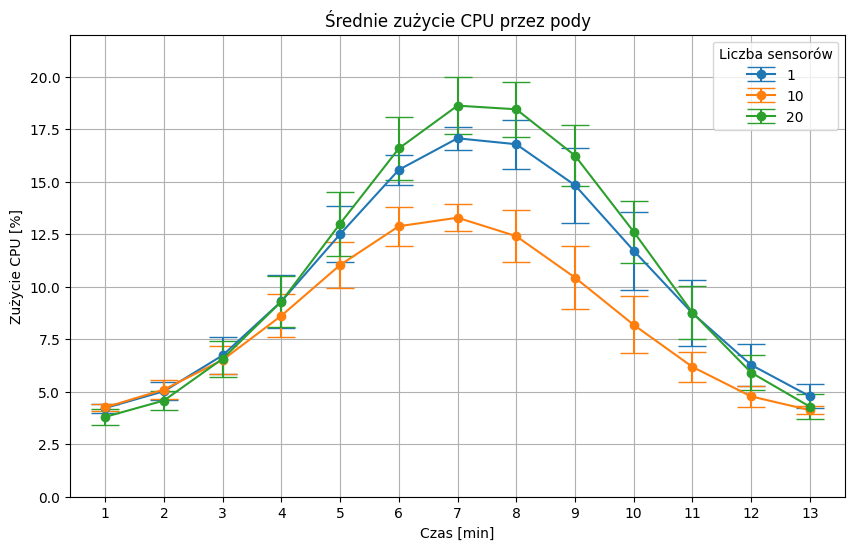

In [ ]:
#microk8s

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

cpu_1_1 = [4.66, 5.67, 7.46, 9.97, 12.57, 13.92, 12.3, 9.43, 7.01, 5.51, 5.27, 4.30, 3.98]
cpu_2_1 = [4.40, 5.29, 6.79, 8.86, 11.01, 12.33, 12.56, 11.52, 9.46, 6.93, 5.56, 4.43, 3.96]
cpu_3_1 = [4.16, 4.66, 5.77, 7.47, 9.63, 11.66, 12.68, 12.44, 11.29, 9.14, 6.68, 5.52, 4.34]
cpu_4_1 = [4.14, 4.65, 5.39, 6.96, 9.13, 11.46, 12.96, 13.31, 11.95, 9.70, 7.36, 5.59, 4.50]
cpu_5_1 = [4.11, 5.09, 6.75, 9.12, 11.20, 13.24, 13.61, 12.71, 10.21, 7.78, 5.88, 4.68, 4.11]
cpu_6_1 = [4.12, 5.23, 6.65, 9.03, 11.65, 13.64, 13.98, 13.13, 10.53, 8.39, 6.22, 4.78, 4.02]
cpu_7_1 = [4.29, 5.48, 7.04, 9.50, 12.00, 13.69, 13.66, 12.14, 10.11, 7.54, 5.32, 4.32, 3.92]
cpu_8_1 = [4.34, 5.69, 7.17, 9.59, 12.09, 13.80, 13.92, 12.69, 10.33, 7.79, 5.82, 4.43, 4.09]
cpu_9_1 = [4.16, 4.60, 5.95, 7.82, 10.14, 12.12, 13.12, 12.77, 11.14, 9.24, 6.74, 4.38, 3.97]
cpu_10_1 = [4.18, 4.67, 6.17, 7.88, 10.93, 12.94, 14.08, 13.94, 12.34, 9.84, 6.99, 5.35, 4.35]

cpu_1 = [4.44, 5.52, 7.56, 10.00, 14.07, 18.02, 20.29, 19.86, 17.84, 13.83, 9.18, 6.36, 4.87, 4.10]
cpu_2 = [4.13, 5.16, 7.37, 10.67, 14.85, 18.59, 20.30, 19.60, 16.84, 12.68, 8.47, 5.68, 4.44, 4.00]
cpu_3 = [4.08, 4.69, 6.87, 9.37, 14.04, 17.80, 19.70, 19.58, 17.07, 13.01, 8.99, 6.03, 4.19, 3.49]
cpu_4 = [3.62, 4.30, 6.09, 8.94, 12.05, 16.11, 18.74, 18.95, 16.92, 13.91, 9.30, 6.63, 4.33, 4.08]
cpu_5 = [3.47, 4.25, 7.92, 11.46, 15.03, 18.16, 19.15, 17.70, 14.60, 10.73, 7.36, 5.29, 4.16, 4.08]
cpu_6 = [3.94, 4.34, 6.35, 8.09, 11.52, 15.45, 18.32, 18.99, 17.32, 13.96, 10.96, 7.06, 5.34, 4.25]
cpu_7 = [3.79, 4.60, 6.01, 8.64, 13.11, 16.35, 18.85, 19.04, 17.11, 13.62, 9.68, 6.75, 4.59, 4.04]
cpu_8 = [3.84, 4.19, 5.39, 7.50, 10.67, 14.06, 16.19, 16.50, 14.82, 11.52, 7.92, 5.20, 3.47, 2.82]
cpu_9 = [3.20, 4.13, 5.47, 8.56, 11.40, 15.17, 17.63, 18.18, 16.61, 13.24, 9.29, 5.84, 4.22, 3.71]
cpu_10 = [3.52, 4.63, 6.68, 9.72, 13.29, 16.12, 17.05, 16.10, 13.32, 9.69, 6.57, 4.28, 3.30, 3.20]


cpu_1_20 = [4.46, 4.93, 6.38, 8.75, 11.92, 15.96, 17.58, 17.54, 16.13, 12.98, 9.47, 6.76, 5.02, 4.21]
cpu_2_20 = [4.29, 4.90, 6.40, 8.81, 12.08, 15.41, 17.52, 17.80, 16.23, 13.13, 10.22, 7.03, 5.29, 4.34]
cpu_3_20 = [4.40, 4.91, 6.33, 8.72, 11.93, 15.47, 17.65, 18.07, 16.56, 13.42, 9.83, 7.09, 5.10, 4.52]
cpu_4_20 = [4.18, 4.60, 6.85, 9.44, 12.80, 16.02, 17.76, 17.40, 15.15, 11.74, 8.98, 6.51, 4.97, 4.94]
cpu_5_20 = [4.41, 4.82, 6.09, 8.23, 11.14, 14.42, 16.77, 17.34, 16.17, 13.48, 10.13, 7.34, 5.48, 4.48]
cpu_6_20 = [3.97, 4.80, 6.50, 9.03, 12.30, 15.30, 16.79, 16.55, 14.64, 11.39, 8.25, 5.95, 4.41, 3.99]
cpu_7_20 = [4.22, 5.19, 7.05, 9.75, 13.03, 15.76, 16.84, 15.94, 13.46, 10.19, 7.73, 5.64, 4.28, 3.92]
cpu_8_20 = [4.42, 5.67, 7.37, 10.39, 14.05, 16.39, 17.13, 15.90, 13.17, 9.83, 7.03, 5.11, 3.91, 3.45]
cpu_9_20 = [3.85, 5.85, 8.77, 12.20, 15.12, 16.50, 16.18, 14.18, 11.00, 8.00, 5.55, 4.36, 4.04, 3.80]
cpu_10_20 = [4.02, 4.57, 5.61, 7.70, 10.65, 14.44, 16.46, 17.14, 15.85, 13.02, 10.23, 7.00, 5.33, 4.14]



df1 = pd.DataFrame({
    '1': [cpu_1[0], cpu_2[0], cpu_3[0], cpu_4[0], cpu_5[0], cpu_6[0], cpu_7[0], cpu_8[0], cpu_9[0], cpu_10[0]],
    '2': [cpu_1[1], cpu_2[1], cpu_3[1], cpu_4[1], cpu_5[1], cpu_6[1], cpu_7[1], cpu_8[1], cpu_9[1], cpu_10[1]],
    '3': [cpu_1[2], cpu_2[2], cpu_3[2], cpu_4[2], cpu_5[2], cpu_6[2], cpu_7[2], cpu_8[2], cpu_9[2], cpu_10[2]], 
    '4': [cpu_1[3], cpu_2[3], cpu_3[3], cpu_4[3], cpu_5[3], cpu_6[3], cpu_7[3], cpu_8[3], cpu_9[3], cpu_10[3]],
    '5': [cpu_1[4], cpu_2[4], cpu_3[4], cpu_4[4], cpu_5[4], cpu_6[4], cpu_7[4], cpu_8[4], cpu_9[4], cpu_10[4]],
    '6': [cpu_1[5], cpu_2[5], cpu_3[5], cpu_4[5], cpu_5[5], cpu_6[5], cpu_7[5], cpu_8[5], cpu_9[5], cpu_10[5]],
    '7': [cpu_1[6], cpu_2[6], cpu_3[6], cpu_4[6], cpu_5[6], cpu_6[6], cpu_7[6], cpu_8[6], cpu_9[6], cpu_10[6]],
    '8': [cpu_1[7], cpu_2[7], cpu_3[7], cpu_4[7], cpu_5[7], cpu_6[7], cpu_7[7], cpu_8[7], cpu_9[7], cpu_10[7]],
    '9': [cpu_1[8], cpu_2[8], cpu_3[8], cpu_4[8], cpu_5[8], cpu_6[8], cpu_7[8], cpu_8[8], cpu_9[8], cpu_10[8]],
    '10': [cpu_1[9], cpu_2[9], cpu_3[9], cpu_4[9], cpu_5[9], cpu_6[9], cpu_7[9], cpu_8[9], cpu_9[9], cpu_10[9]], 
    '11': [cpu_1[10], cpu_2[10], cpu_3[10], cpu_4[10], cpu_5[10], cpu_6[10], cpu_7[10], cpu_8[10], cpu_9[10], cpu_10[10]],
    '12': [cpu_1[11], cpu_2[11], cpu_3[11], cpu_4[11], cpu_5[11], cpu_6[11], cpu_7[11], cpu_8[11], cpu_9[11], cpu_10[11]],
    '13': [cpu_1[12], cpu_2[12], cpu_3[12], cpu_4[12], cpu_5[12], cpu_6[12], cpu_7[12], cpu_8[12], cpu_9[12], cpu_10[12]]},
    )

df2 = pd.DataFrame({
    '1' : [cpu_1_1[0], cpu_2_1[0], cpu_3_1[0], cpu_4_1[0], cpu_5_1[0], cpu_6_1[0], cpu_7_1[0], cpu_8_1[0], cpu_9_1[0], cpu_10_1[0]],
    '2' : [cpu_1_1[1], cpu_2_1[1], cpu_3_1[1], cpu_4_1[1], cpu_5_1[1], cpu_6_1[1], cpu_7_1[1], cpu_8_1[1], cpu_9_1[1], cpu_10_1[1]],
    '3' : [cpu_1_1[2], cpu_2_1[2], cpu_3_1[2], cpu_4_1[2], cpu_5_1[2], cpu_6_1[2], cpu_7_1[2], cpu_8_1[2], cpu_9_1[2], cpu_10_1[2]],
    '4' : [cpu_1_1[3], cpu_2_1[3], cpu_3_1[3], cpu_4_1[3], cpu_5_1[3], cpu_6_1[3], cpu_7_1[3], cpu_8_1[3], cpu_9_1[3], cpu_10_1[3]], 
    '5' : [cpu_1_1[4], cpu_2_1[4], cpu_3_1[4], cpu_4_1[4], cpu_5_1[4], cpu_6_1[4], cpu_7_1[4], cpu_8_1[4], cpu_9_1[4], cpu_10_1[4]],
    '6' : [cpu_1_1[5], cpu_2_1[5], cpu_3_1[5], cpu_4_1[5], cpu_5_1[5], cpu_6_1[5], cpu_7_1[5], cpu_8_1[5], cpu_9_1[5], cpu_10_1[5]],
    '7' : [cpu_1_1[6], cpu_2_1[6], cpu_3_1[6], cpu_4_1[6], cpu_5_1[6], cpu_6_1[6], cpu_7_1[6], cpu_8_1[6], cpu_9_1[6], cpu_10_1[6]],
    '8' : [cpu_1_1[7], cpu_2_1[7], cpu_3_1[7], cpu_4_1[7], cpu_5_1[7], cpu_6_1[7], cpu_7_1[7], cpu_8_1[7], cpu_9_1[7], cpu_10_1[7]],
    '9' : [cpu_1_1[8], cpu_2_1[8], cpu_3_1[8], cpu_4_1[8], cpu_5_1[8], cpu_6_1[8], cpu_7_1[8], cpu_8_1[8], cpu_9_1[8], cpu_10_1[8]],
    '10': [cpu_1_1[9], cpu_2_1[9], cpu_3_1[9], cpu_4_1[9], cpu_5_1[9], cpu_6_1[9], cpu_7_1[9], cpu_8_1[9], cpu_9_1[9], cpu_10_1[9]],
    '11': [cpu_1_1[10], cpu_2_1[10], cpu_3_1[10], cpu_4_1[10], cpu_5_1[10], cpu_6_1[10], cpu_7_1[10], cpu_8_1[10], cpu_9_1[10], cpu_10_1[10]],
    '12': [cpu_1_1[11], cpu_2_1[11], cpu_3_1[11], cpu_4_1[11], cpu_5_1[11], cpu_6_1[11], cpu_7_1[11], cpu_8_1[11], cpu_9_1[11], cpu_10_1[11]],
    '13': [cpu_1_1[12], cpu_2_1[12], cpu_3_1[12], cpu_4_1[12], cpu_5_1[12], cpu_6_1[12], cpu_7_1[12], cpu_8_1[12], cpu_9_1[12], cpu_10_1[12]]})

df3 = pd.DataFrame({
    '1' : [cpu_1_20[0], cpu_2_20[0], cpu_3_20[0], cpu_4_20[0], cpu_5_20[0], cpu_6_20[0], cpu_7_20[0], cpu_8_20[0], cpu_9_20[0], cpu_10_20[0]],
    '2' : [cpu_1_20[1], cpu_2_20[1], cpu_3_20[1], cpu_4_20[1], cpu_5_20[1], cpu_6_20[1], cpu_7_20[1], cpu_8_20[1], cpu_9_20[1], cpu_10_20[1]],
    '3' : [cpu_1_20[2], cpu_2_20[2], cpu_3_20[2], cpu_4_20[2], cpu_5_20[2], cpu_6_20[2], cpu_7_20[2], cpu_8_20[2], cpu_9_20[2], cpu_10_20[2]],
    '4' : [cpu_1_20[3], cpu_2_20[3], cpu_3_20[3], cpu_4_20[3], cpu_5_20[3], cpu_6_20[3], cpu_7_20[3], cpu_8_20[3], cpu_9_20[3], cpu_10_20[3]],
    '5' : [cpu_1_20[4], cpu_2_20[4], cpu_3_20[4], cpu_4_20[4], cpu_5_20[4], cpu_6_20[4], cpu_7_20[4], cpu_8_20[4], cpu_9_20[4], cpu_10_20[4]],
    '6' : [cpu_1_20[5], cpu_2_20[5], cpu_3_20[5], cpu_4_20[5], cpu_5_20[5], cpu_6_20[5], cpu_7_20[5], cpu_8_20[5], cpu_9_20[5], cpu_10_20[5]],
    '7' : [cpu_1_20[6], cpu_2_20[6], cpu_3_20[6], cpu_4_20[6], cpu_5_20[6], cpu_6_20[6], cpu_7_20[6], cpu_8_20[6], cpu_9_20[6], cpu_10_20[6]],
    '8' : [cpu_1_20[7], cpu_2_20[7], cpu_3_20[7], cpu_4_20[7], cpu_5_20[7], cpu_6_20[7], cpu_7_20[7], cpu_8_20[7], cpu_9_20[7], cpu_10_20[7]],
    '9' : [cpu_1_20[8], cpu_2_20[8], cpu_3_20[8], cpu_4_20[8], cpu_5_20[8], cpu_6_20[8], cpu_7_20[8], cpu_8_20[8], cpu_9_20[8], cpu_10_20[8]],
    '10': [cpu_1_20[9], cpu_2_20[9], cpu_3_20[9], cpu_4_20[9], cpu_5_20[9], cpu_6_20[9], cpu_7_20[9], cpu_8_20[9], cpu_9_20[9], cpu_10_20[9]],
    '11': [cpu_1_20[10], cpu_2_20[10], cpu_3_20[10], cpu_4_20[10], cpu_5_20[10], cpu_6_20[10], cpu_7_20[10], cpu_8_20[10], cpu_9_20[10], cpu_10_20[10]],
    '12': [cpu_1_20[11], cpu_2_20[11], cpu_3_20[11], cpu_4_20[11], cpu_5_20[11], cpu_6_20[11], cpu_7_20[11], cpu_8_20[11], cpu_9_20[11], cpu_10_20[11]],
    '13': [cpu_1_20[12], cpu_2_20[12], cpu_3_20[12], cpu_4_20[12], cpu_5_20[12], cpu_6_20[12], cpu_7_20[12], cpu_8_20[12], cpu_9_20[12], cpu_10_20[12]]})

cols = ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13']
means1 = []
std1 = []

means2 = []
std2 = []

means3 = []
std3 = []
for col in cols:
    means2.append(df2[col].mean())
    std2.append(df2[col].std()) 

for col in cols:
    means3.append(df3[col].mean())
    std3.append(df3[col].std())

for col in cols:
    means1.append(df1[col].mean())
    std1.append(df1[col].std())
plt.figure(figsize=(10, 6))
plt.errorbar(cols, means3, yerr=std3, fmt='o-', capsize=10)
plt.errorbar(cols, means2, yerr=std2, fmt='o-', capsize=10)
plt.errorbar(cols, means1, yerr=std1, fmt='o-', capsize=10)
plt.legend(['1', '10', '20'], title="Liczba sensorów")
plt.title("Średnie zużycie CPU przez pody")
plt.ylim(0, 22)
plt.xlabel("Czas [min]")
plt.ylabel("Zużycie CPU [%]")
plt.grid()
plt.show()

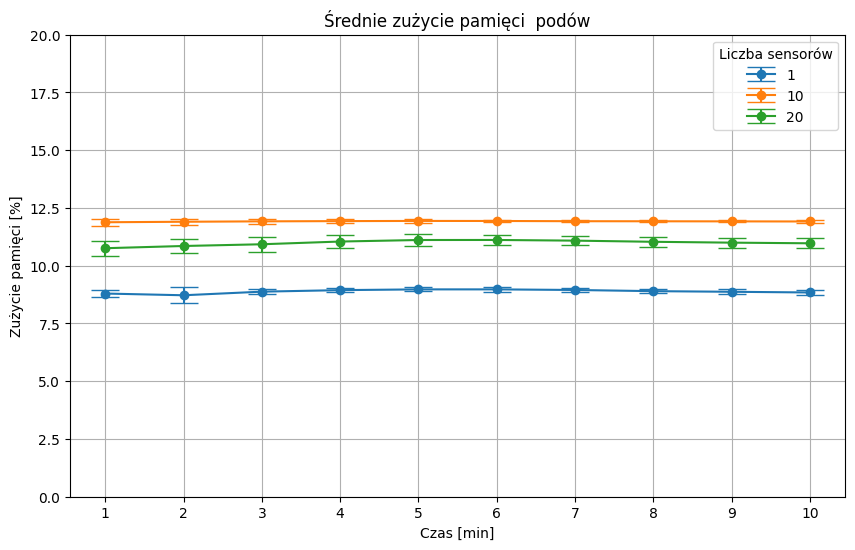

In [ ]:


#micro
mem_1_1 = [8.47, 8.48, 8.61, 8.75, 8.87, 8.91, 8.86, 8.80, 8.72, 8.66]
mem_2_1 = [8.74, 8.83, 8.92, 9.01, 9.06, 9.04, 8.98, 8.88, 8.80, 8.75]
mem_3_1 = [8.75, 7.79, 8.88, 8.97, 9.05, 9.06, 8.99, 8.92, 8.85, 8.82]
mem_4_1 = [8.97, 8.99, 9.04, 9.08, 9.11, 9.11, 9.08, 9.01, 9.01, 8.86]
mem_5_1 = [8.84, 8.83, 8.86, 8.88, 8.91, 8.95, 8.97, 8.99, 9.04, 9.07]
mem_6_1 = [8.92, 8.93, 8.95, 8.97, 8.91, 8.80, 8.81, 8.83, 8.84, 8.84]
mem_7_1 = [8.82, 8.83, 8.85, 9.01, 9.03, 9.04, 9.02, 8.85, 8.81, 8.80]
mem_8_1 = [8.75, 8.77, 8.81, 8.84, 8.85, 8.86, 8.83, 8.82, 8.81, 8.81]
mem_9_1 = [8.88, 8.89, 8.94, 8.99, 9.03, 9.04, 9.01, 8.95, 8.92, 8.91]
mem_10_1 = [8.82, 8.87, 8.91, 8.93, 8.94, 8.95, 8.95, 8.94, 8.92, 8.90]


# 10
mem_1 = [11.47, 11.56, 11.65, 11.73, 11.79, 11.83, 11.84, 11.86, 11.85, 11.82]
mem_2 = [11.81, 11.83, 11.84, 11.85, 11.87, 11.88, 11.90, 11.91, 11.91, 11.90]
mem_3 = [11.91, 11.92, 11.94, 11.95, 11.96, 11.93, 11.89, 11.86, 11.83, 11.82]
mem_4 = [11.87, 11.89, 11.89, 11.89, 11.87, 11.87, 11.86, 11.88, 11.90, 11.92]
mem_5 = [12.02, 12.04, 12.04, 12.02, 11.98, 11.97, 11.97, 11.96, 11.96, 11.96]
mem_6 = [11.95, 11.95, 11.96, 11.97, 11.99, 11.97, 11.97, 11.95, 11.94, 11.93]
mem_7 = [11.97, 11.98, 12.01, 11.99, 11.99, 11.98, 11.96, 11.96, 11.97, 11.97]
mem_8 = [11.89, 11.90, 11.91, 11.93, 11.95, 11.96, 11.94, 11.93, 11.92, 11.90]
mem_9 = [11.92, 11.93, 11.94, 11.96, 11.98, 11.97, 11.96, 11.96, 11.96, 11.97]
mem_10 = [12.01, 12.03, 12.03, 12.02, 12.01, 12.01, 11.98, 11.97, 11.96, 11.96]



mem_1_20 = [10.24, 10.43, 10.57, 10.77, 10.89, 10.81, 10.79, 10.69, 10.65, 10.65]
mem_2_20 = [10.58, 10.59, 10.66, 10.74, 10.85, 10.93, 10.91, 10.85, 10.78, 10.70]
mem_3_20 = [10.62, 10.65, 10.75, 10.84, 10.93, 10.95, 10.94, 10.88, 10.80, 10.78]
mem_4_20 = [10.56, 10.59, 10.61, 10.84, 10.98, 11.07, 11.07, 11.02, 10.98, 10.93]
mem_5_20 = [10.72, 10.74, 10.75, 10.78, 10.83, 10.87, 10.90, 10.94, 10.95, 10.95]
mem_6_20 = [11.07, 11.16, 11.24, 11.32, 11.33, 11.29, 11.22, 11.13, 11.05, 11.04]
mem_7_20 = [11.10, 11.21, 11.30, 11.31, 11.32, 11.24, 11.16, 11.11, 11.11, 11.11]
mem_8_20 = [11.18, 11.27, 11.34, 11.41, 11.40, 11.38, 11.37, 11.35, 11.34, 11.30]
mem_9_20 = [10.47, 10.76, 10.82, 11.10, 11.16, 11.17, 11.11, 11.06, 11.04, 11.02]
mem_10_20 = [11.04, 11.14, 11.25, 11.36, 11.44, 11.44, 11.39, 11.33, 11.29, 11.23]



df1= pd.DataFrame({
    '1' : [mem_1[0], mem_2[0], mem_3[0], mem_4[0], mem_5[0], mem_6[0], mem_7[0], mem_8[0], mem_9[0], mem_10[0]],
    '2' : [mem_1[1], mem_2[1], mem_3[1], mem_4[1], mem_5[1], mem_6[1], mem_7[1], mem_8[1], mem_9[1], mem_10[1]],
    '3' : [mem_1[2], mem_2[2], mem_3[2], mem_4[2], mem_5[2], mem_6[2], mem_7[2], mem_8[2], mem_9[2], mem_10[2]],
    '4' : [mem_1[3], mem_2[3], mem_3[3], mem_4[3], mem_5[3], mem_6[3], mem_7[3], mem_8[3], mem_9[3], mem_10[3]],
    '5' : [mem_1[4], mem_2[4], mem_3[4], mem_4[4], mem_5[4], mem_6[4], mem_7[4], mem_8[4], mem_9[4], mem_10[4]],
    '6' : [mem_1[5], mem_2[5], mem_3[5], mem_4[5], mem_5[5], mem_6[5], mem_7[5], mem_8[5], mem_9[5], mem_10[5]],
    '7' : [mem_1[6], mem_2[6], mem_3[6], mem_4[6], mem_5[6], mem_6[6], mem_7[6], mem_8[6], mem_9[6], mem_10[6]],
    '8' : [mem_1[7], mem_2[7], mem_3[7], mem_4[7], mem_5[7], mem_6[7], mem_7[7], mem_8[7], mem_9[7], mem_10[7]],
    '9' : [mem_1[8], mem_2[8], mem_3[8], mem_4[8], mem_5[8], mem_6[8], mem_7[8], mem_8[8], mem_9[8], mem_10[8]],
    '10': [mem_1[9], mem_2[9], mem_3[9], mem_4[9], mem_5[9], mem_6[9], mem_7[9], mem_8[9], mem_9[9], mem_10[9]]})

df2 = pd.DataFrame({
    '1' : [mem_1_1[0], mem_2_1[0], mem_3_1[0], mem_4_1[0], mem_5_1[0], mem_6_1[0], mem_7_1[0], mem_8_1[0], mem_9_1[0], mem_10_1[0]],
    '2' : [mem_1_1[1], mem_2_1[1], mem_3_1[1], mem_4_1[1], mem_5_1[1], mem_6_1[1], mem_7_1[1], mem_8_1[1], mem_9_1[1], mem_10_1[1]],
    '3' : [mem_1_1[2], mem_2_1[2], mem_3_1[2], mem_4_1[2], mem_5_1[2], mem_6_1[2], mem_7_1[2], mem_8_1[2], mem_9_1[2], mem_10_1[2]],
    '4' : [mem_1_1[3], mem_2_1[3], mem_3_1[3], mem_4_1[3], mem_5_1[3], mem_6_1[3], mem_7_1[3], mem_8_1[3], mem_9_1[3], mem_10_1[3]],
    '5' : [mem_1_1[4], mem_2_1[4], mem_3_1[4], mem_4_1[4], mem_5_1[4], mem_6_1[4], mem_7_1[4], mem_8_1[4], mem_9_1[4], mem_10_1[4]],
    '6' : [mem_1_1[5], mem_2_1[5], mem_3_1[5], mem_4_1[5], mem_5_1[5], mem_6_1[5], mem_7_1[5], mem_8_1[5], mem_9_1[5], mem_10_1[5]],
    '7' : [mem_1_1[6], mem_2_1[6], mem_3_1[6], mem_4_1[6], mem_5_1[6], mem_6_1[6], mem_7_1[6], mem_8_1[6], mem_9_1[6], mem_10_1[6]],
    '8' : [mem_1_1[7], mem_2_1[7], mem_3_1[7], mem_4_1[7], mem_5_1[7], mem_6_1[7], mem_7_1[7], mem_8_1[7], mem_9_1[7], mem_10_1[7]],
    '9' : [mem_1_1[8], mem_2_1[8], mem_3_1[8], mem_4_1[8], mem_5_1[8], mem_6_1[8], mem_7_1[8], mem_8_1[8], mem_9_1[8], mem_10_1[8]],
    '10': [mem_1_1[9], mem_2_1[9], mem_3_1[9], mem_4_1[9], mem_5_1[9], mem_6_1[9], mem_7_1[9], mem_8_1[9], mem_9_1[9], mem_10_1[9]]})

df3 = pd.DataFrame({
    '1' : [mem_1_20[0], mem_2_20[0], mem_3_20[0], mem_4_20[0], mem_5_20[0], mem_6_20[0], mem_7_20[0], mem_8_20[0], mem_9_20[0], mem_10_20[0]],
    '2' : [mem_1_20[1], mem_2_20[1], mem_3_20[1], mem_4_20[1], mem_5_20[1], mem_6_20[1], mem_7_20[1], mem_8_20[1], mem_9_20[1], mem_10_20[1]],
    '3' : [mem_1_20[2], mem_2_20[2], mem_3_20[2], mem_4_20[2], mem_5_20[2], mem_6_20[2], mem_7_20[2], mem_8_20[2], mem_9_20[2], mem_10_20[2]],
    '4' : [mem_1_20[3], mem_2_20[3], mem_3_20[3], mem_4_20[3], mem_5_20[3], mem_6_20[3], mem_7_20[3], mem_8_20[3], mem_9_20[3], mem_10_20[3]],
    '5' : [mem_1_20[4], mem_2_20[4], mem_3_20[4], mem_4_20[4], mem_5_20[4], mem_6_20[4], mem_7_20[4], mem_8_20[4], mem_9_20[4], mem_10_20[4]],
    '6' : [mem_1_20[5], mem_2_20[5], mem_3_20[5], mem_4_20[5], mem_5_20[5], mem_6_20[5], mem_7_20[5], mem_8_20[5], mem_9_20[5], mem_10_20[5]],
    '7' : [mem_1_20[6], mem_2_20[6], mem_3_20[6], mem_4_20[6], mem_5_20[6], mem_6_20[6], mem_7_20[6], mem_8_20[6], mem_9_20[6], mem_10_20[6]],
    '8' : [mem_1_20[7], mem_2_20[7], mem_3_20[7], mem_4_20[7], mem_5_20[7], mem_6_20[7], mem_7_20[7], mem_8_20[7], mem_9_20[7], mem_10_20[7]],
    '9' : [mem_1_20[8], mem_2_20[8], mem_3_20[8], mem_4_20[8], mem_5_20[8], mem_6_20[8], mem_7_20[8], mem_8_20[8], mem_9_20[8], mem_10_20[8]],
    '10': [mem_1_20[9], mem_2_20[9], mem_3_20[9], mem_4_20[9], mem_5_20[9], mem_6_20[9], mem_7_20[9], mem_8_20[9], mem_9_20[9], mem_10_20[9]]})

cols = ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10']
means1 = []
std1 = []

means2 = []
std2 = []

means3 = []
std3 = []

for col in cols:
    means1.append(df1[col].mean())
    std1.append(df1[col].std())


for col in cols:
    means2.append(df2[col].mean())
    std2.append(df2[col].std())


for col in cols:
    means3.append(df3[col].mean())
    std3.append(df3[col].std())
plt.figure(figsize=(10, 6))
plt.errorbar(cols, means2, yerr=std2, fmt='o-', capsize=10)
plt.errorbar(cols, means1, yerr=std1, fmt='o-', capsize=10)
plt.errorbar(cols, means3, yerr=std3, fmt='o-', capsize=10)
plt.legend(['1', '10', '20'], title="Liczba sensorów")
plt.title("Średnie zużycie pamięci RAM przez pody")
plt.ylim(0, 20)
plt.xlabel("Czas [min]")
plt.ylabel("Zużycie pamięci [%]")
plt.grid()
plt.show()

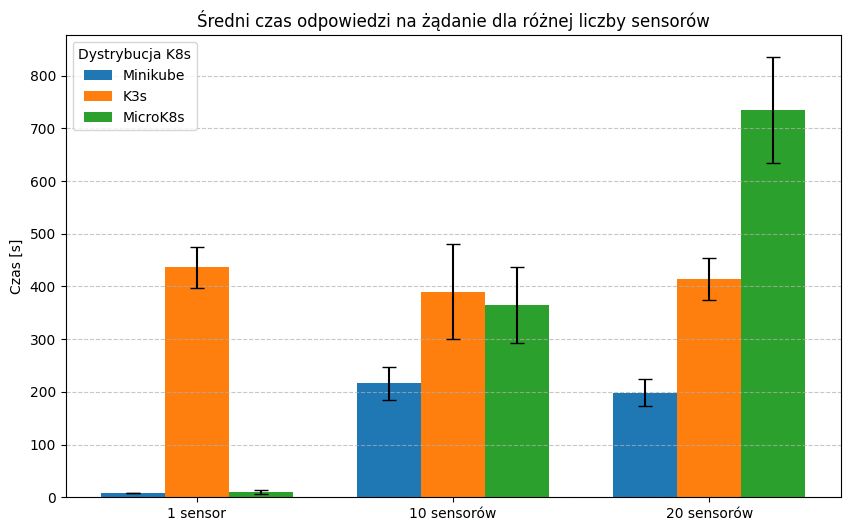

In [32]:
import numpy as np
micro_1 = [11.08, 18.6, 7.37, 14.3, 7.38, 7.58, 7.62, 7.65, 7.47, 8.12]
micro_10 = [324.94, 352.69, 246.33, 244.88, 465.25, 386.15, 421.89, 454.62, 368.12, 377.53]
micro_20 = [637.71, 625.37, 644.24, 623.45, 925.11, 728.91, 804.04, 710.57, 837.02, 811.6]

k3s_1 = [421.59, 525.77, 484.88, 443.85, 407.11, 423.05, 398, 426.95, 434.02, 394.71]
k3s_10 = [420.65, 208.48, 241.16, 359.24, 385.09, 434.86, 470.75, 489.73, 434, 452.89]
k3s_20 = [383.54, 359.26, 393.81, 429.68, 421.95, 397.76, 413.72, 385.15, 501.95, 460.49]

mini_1 = [8.61, 8.24, 7.64, 8.08, 9.05, 8.53, 8.66, 9.36, 8.72, 8.31]
mini_10 = [282.78, 192.84, 200.06, 199.5, 245.39, 251.33, 190, 224.73, 193.24, 186.15]
mini_20 = [225.89, 256.45, 177.88, 172.8, 199.8, 202.44, 177.88, 206.18, 200.32, 165.8]

means = [
    [np.mean(mini_1), np.mean(k3s_1), np.mean(micro_1)],
    [np.mean(mini_10), np.mean(k3s_10), np.mean(micro_10)],
    [np.mean(mini_20), np.mean(k3s_20), np.mean(micro_20)]
]
stdevs = [
    [np.std(mini_1), np.std(k3s_1), np.std(micro_1)],
    [np.std(mini_10), np.std(k3s_10), np.std(micro_10)],
    [np.std(mini_20), np.std(k3s_20), np.std(micro_20)]
]

# Plotting setup
sensor_labels = ['1 sensor', '10 sensorów', '20 sensorów']
distros = ['Minikube', 'K3s', 'MicroK8s']
colors = ['tab:blue', 'tab:orange', 'tab:green']
x = np.arange(len(sensor_labels))  # [0, 1, 2]
width = 0.25  # width of each bar

plt.figure(figsize=(10, 6))

# Plot each distro as a separate bar in each sensor group
for i in range(3):  # 0 = Minikube, 1 = K3s, 2 = MicroK8s
    distro_means = [means[j][i] for j in range(3)]
    distro_stdevs = [stdevs[j][i] for j in range(3)]
    plt.bar(x + i*width, distro_means, width, yerr=distro_stdevs, capsize=5,
            label=distros[i], color=colors[i])

# Axis and label settings
plt.ylabel('Czas [s]')
plt.title('Średni czas odpowiedzi na żądanie dla różnej liczby sensorów')
plt.xticks(x + width, sensor_labels)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Dystrybucja K8s')
# plt.tight_layout()

plt.show()